In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit.cost import LeastSquares

In [3]:
sys.path.append('/home/masson/afterglowpy/orphan_modules')
from features import compute_duration_between_first_and_peak, compute_rates, compute_colours
from tools import flux_to_mag, mag_to_flux

In [4]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

### Import data

In [63]:
orphans_ztf = pd.read_pickle('/home/masson/orphans/data/pseudo_obs/orphan_pseudo_obs_ztf.pkl')
df_orphans_ztf = pd.DataFrame(data=orphans_ztf)

In [64]:
df_orphans_ztf

,config,time,flux,flux_err,mags,filt,zp
0,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[58700.457, 58701.453, 58703.457, 58703.5, 587...","[-28.571483330376143, -39.20548649262819, -7.8...","[84.33324487654035, 44.170161578018565, 79.889...","[nan, nan, nan, 22.810933238780038, 24.2103602...","[ztfr, ztfg, ztfr, ztfg, ztfr, ztfr, ztfg, ztf...","[26.152996, 26.087868, 26.149637, 26.122215, 2..."
1,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[59739.223, 59742.207, 59748.184, 59748.184, 5...","[-102.78418792258906, 439.73110867196016, 203....","[51.77334259931948, 25.762348836662007, 56.505...","[nan, 19.092728968276326, 20.4972773290328, 20...","[ztfi, ztfi, ztfr, ztfr, ztfr, ztfr, ztfr, ztf...","[25.68966, 25.700697, 26.26771, 26.279907, 26...."
2,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[58778.32, 58778.324, 58779.324, 58781.32, 587...","[-53.52637011209429, -36.61454810399483, 7.779...","[54.23165597477047, 44.70228257464092, 44.3501...","[nan, nan, 23.94434817600413, nan, 18.30731279...","[ztfr, ztfr, ztfr, ztfr, ztfr, ztfg, ztfg, ztf...","[26.149136, 26.148851, 26.17168, 23.418282, 23..."
3,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[58762.16, 58762.188, 58762.215, 58762.227, 58...","[-47.13282064133121, -59.900050857070646, -1.0...","[39.03193648065544, 50.15487731766613, 32.7419...","[nan, nan, nan, nan, 21.35047161870034, nan, n...","[ztfr, ztfg, ztfr, ztfr, ztfg, ztfg, ztfr, ztf...","[26.186712, 26.261314, 26.18021, 26.190859, 26..."
4,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[59265.344, 59265.363, 59265.43, 59267.387, 59...","[35.611131470656474, -4.644683245353506, -68.5...","[55.691971621817366, 41.60390471693319, 71.846...","[21.964175216662987, nan, nan, nan, 23.0022172...","[ztfi, ztfr, ztfg, ztfg, ztfr, ztfi, ztfr, ztf...","[25.84314, 26.396542, 26.416092, 26.391092, 26..."
...,...,...,...,...,...,...,...
1200,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[58849.42, 58849.465, 58852.434, 58852.477, 58...","[20466.56566644738, 18010.762829523155, 11928....","[76.79822735314916, 82.95075448642113, 51.9002...","[15.413313165064645, 15.613391792762386, 16.01...","[ztfr, ztfg, ztfr, ztfg, ztfr, ztfg, ztfr, ztf...","[26.190926, 26.252222, 26.201538, 26.252377, 2..."
1201,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[59329.426, 59334.363, 59334.363, 59334.43, 59...","[27.821253267486327, -21.520414797530396, -9.1...","[46.922044101429414, 37.493064137233134, 16.17...","[22.62770955109802, nan, nan, 20.4728407597439...","[ztfr, ztfr, ztfr, ztfi, ztfg, ztfg, ztfr, ztf...","[26.238651, 26.250446, 26.245466, 25.685791, 2..."
1202,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[59082.44, 59082.496, 59086.426, 59086.438, 59...","[-58.217765287410856, 80.80293383181392, 863.8...","[41.84998378229348, 65.30684784155667, 20.7036...","[nan, 21.43338606385459, 18.911337723952194, 1...","[ztfg, ztfr, ztfr, ztfr, ztfg, ztfr, ztfg, ztf...","[25.912846, 26.201954, 26.252462, 26.259731, 2..."
1203,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[58326.164, 58326.312, 58330.273, 58330.332, 5...","[-45.80308099712004, -54.116186248452586, 1447...","[53.90952662143333, 60.08969126309444, 39.4472...","[nan, nan, 18.195702236603985, 17.889527015709...","[ztfg, ztfr, ztfg, ztfr, ztfr, ztfr, ztfr, ztf...","[26.172813, 26.103493, 26.097279, 26.040272, 2..."


**Magnitude from flux:**
$$ m = -2.5 \times \log_{⁡10}(F) + z_P $$

**Error propagation:**

Let $\sigma_F$ be the flux uncertainty. The derivative of magnitude with respect to flux is:
$$ \frac{dm}{dF} = -2.5 \times \frac{1}{\ln⁡(10)} \frac{1}{F} $$

So the magnitude error is:
$$ \sigma_m = \left\lvert\frac{dm}{dF}\right\rvert\sigma_F = \frac{2.5}{\ln⁡(10)} \times \frac{\sigma_F}{F} \approx 1.0857 \frac{\sigma_F}{F} $$ 

In [154]:
df_orphans_ztf['mags_err'] = 1.0857 * df_orphans_ztf['flux_err'] / df_orphans_ztf['flux']

# transform filters in LSST format ['g', 'r', 'i']
filter_map = {'ztfg': 'g', 'ztfr': 'r', 'ztfi': 'i'}
df_orphans_ztf['filt'] = df_orphans_ztf['filt'].apply(lambda flist: [filter_map.get(f, f) for f in flist])

In [8]:
df_orphans_ztf

,config,time,flux,flux_err,mags,filt,zp,mags_err
0,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[58700.457, 58701.453, 58703.457, 58703.5, 587...","[-28.571483330376143, -39.20548649262819, -7.8...","[84.33324487654035, 44.170161578018565, 79.889...","[nan, nan, nan, 22.810933238780038, 24.2103602...","[r, g, r, g, r, r, g, r, r, g, r, g, r, r, r, ...","[26.152996, 26.087868, 26.149637, 26.122215, 2...","[-3.2046149968390343, -1.223184526335921, -11...."
1,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[59739.223, 59742.207, 59748.184, 59748.184, 5...","[-102.78418792258906, 439.73110867196016, 203....","[51.77334259931948, 25.762348836662007, 56.505...","[nan, 19.092728968276326, 20.4972773290328, 20...","[i, i, r, r, r, r, r, r, r, r, r, r, r, r, r, ...","[25.68966, 25.700697, 26.26771, 26.279907, 26....","[-0.5468770945820522, 0.06360746733711244, 0.3..."
2,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[58778.32, 58778.324, 58779.324, 58781.32, 587...","[-53.52637011209429, -36.61454810399483, 7.779...","[54.23165597477047, 44.70228257464092, 44.3501...","[nan, nan, 23.94434817600413, nan, 18.30731279...","[r, r, r, r, r, g, g, r, g, g, r, g, r, g, r, ...","[26.149136, 26.148851, 26.17168, 23.418282, 23...","[-1.100005637753951, -1.3255186996556823, 6.18..."
3,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[58762.16, 58762.188, 58762.215, 58762.227, 58...","[-47.13282064133121, -59.900050857070646, -1.0...","[39.03193648065544, 50.15487731766613, 32.7419...","[nan, nan, nan, nan, 21.35047161870034, nan, n...","[r, g, r, r, g, g, r, g, r, r, g, g, g, g, r, ...","[26.186712, 26.261314, 26.18021, 26.190859, 26...","[-0.8990969108241075, -0.9090668459317748, -35..."
4,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[59265.344, 59265.363, 59265.43, 59267.387, 59...","[35.611131470656474, -4.644683245353506, -68.5...","[55.691971621817366, 41.60390471693319, 71.846...","[21.964175216662987, nan, nan, nan, 23.0022172...","[i, r, g, g, r, i, r, g, i, g, r, g, r, r, g, ...","[25.84314, 26.396542, 26.416092, 26.391092, 26...","[1.6979177884204555, -9.724960124323081, -1.13..."
...,...,...,...,...,...,...,...,...
1200,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[58849.42, 58849.465, 58852.434, 58852.477, 58...","[20466.56566644738, 18010.762829523155, 11928....","[76.79822735314916, 82.95075448642113, 51.9002...","[15.413313165064645, 15.613391792762386, 16.01...","[r, g, r, g, r, g, r, g, r, g, r, g, g, g, r, ...","[26.190926, 26.252222, 26.201538, 26.252377, 2...","[0.004073953431962739, 0.005000323140021705, 0..."
1201,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[59329.426, 59334.363, 59334.363, 59334.43, 59...","[27.821253267486327, -21.520414797530396, -9.1...","[46.922044101429414, 37.493064137233134, 16.17...","[22.62770955109802, nan, nan, 20.4728407597439...","[r, r, r, i, g, g, r, g, r, r, g, g, i, g, r, ...","[26.238651, 26.250446, 26.245466, 25.685791, 2...","[1.8310916043619585, -1.891516502668216, -1.91..."
1202,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[59082.44, 59082.496, 59086.426, 59086.438, 59...","[-58.217765287410856, 80.80293383181392, 863.8...","[41.84998378229348, 65.30684784155667, 20.7036...","[nan, 21.43338606385459, 18.911337723952194, 1...","[g, r, r, r, g, r, g, r, g, r, g, r, g, r, r, ...","[25.912846, 26.201954, 26.252462, 26.259731, 2...","[-0.7804581156305794, 0.8774884937861221, 0.02..."
1203,"{'jetType': 4, 'specType': 0, 'b': 4, 'thetaOb...","[58326.164, 58326.312, 58330.273, 58330.332, 5...","[-45.80308099712004, -54.116186248452586, 1447...","[53.90952662143333, 60.08969126309444, 39.4472...","[nan, nan, 18.195702236603985, 17.889527015709...","[g, r, g, r, r, r, r, r, r, r, r, r, r, r, r, ...","[26.172813, 26.103493, 26.097279, 26.040272, 2...","[-1.2778523142705254, -1.2055427835365453, 0.0..."


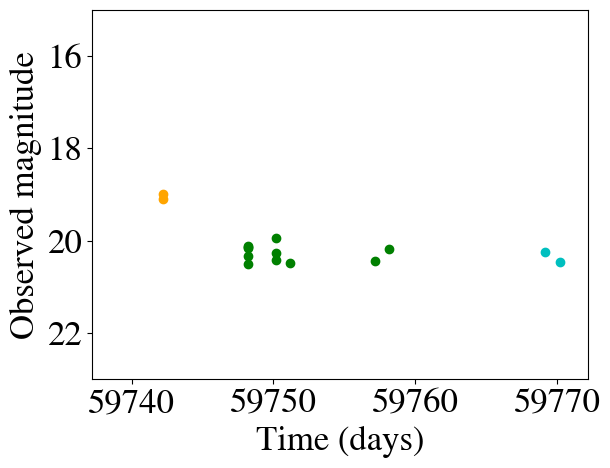

In [69]:
ztf_bands_label = ['$g_{ztf}$', '$r_{ztf}$', '$i_{ztf}$']
ztf_bands = ['g', 'r', 'i']
band_colors = {'g':'c', 'r':'g', 'i':'orange'}

time = np.array(df_orphans_ztf.iloc[1]['time'])
mags = np.array(df_orphans_ztf.iloc[1]['mags'])
filts = np.array(df_orphans_ztf.iloc[1]['filt'])

for b in ztf_bands:
    
    time_one_filt = time[filts == b]
    mags_one_filt = mags[filts == b]
    
    plt.scatter(time_one_filt[mags_one_filt<20.5], mags_one_filt[mags_one_filt<20.5], color=band_colors[b])

plt.xlabel('Time (days)')
plt.ylabel('Observed magnitude')
plt.gca().invert_yaxis()
plt.ylim(23, 15)
plt.xlim(min(time)-2, max(time)+2)

plt.show()


In [13]:
duration = []

for i in range(len(df_orphans_ztf)):
    mask = np.array(df_orphans_ztf.iloc[i]['mags']) < 20.5
    time = np.array(df_orphans_ztf.iloc[i]['time'])[mask]
    if time.size != 0:
        time_sort = np.sort(time)
        duration.append(time_sort[-1] - time_sort[0])
    

In [15]:
max(duration)

54.964844

(array([110., 125., 111.,  94.,  88., 104., 128., 155., 235.,  42.]),
 array([ 0.       ,  5.4964843, 10.992969 , 16.489452 , 21.985937 ,
        27.482422 , 32.978905 , 38.47539  , 43.971874 , 49.46836  ,
        54.964844 ], dtype=float32),
 <BarContainer object of 10 artists>)

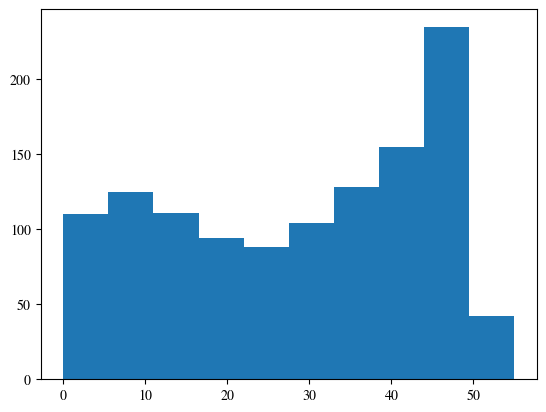

In [14]:
plt.hist(duration)

### Compute straightforward features

#### Rise time

In [260]:
dt_po = []

for i in range(len(df_orphans_ztf)):
    
    p = df_orphans_ztf.iloc[i]
    
    mask = np.array(p['mags'])<20.8
    times = np.array(p['time'])[mask]
    mags = np.array(p['mags'])[mask]
    dt_po.append(compute_duration_between_first_and_peak(times, mags))

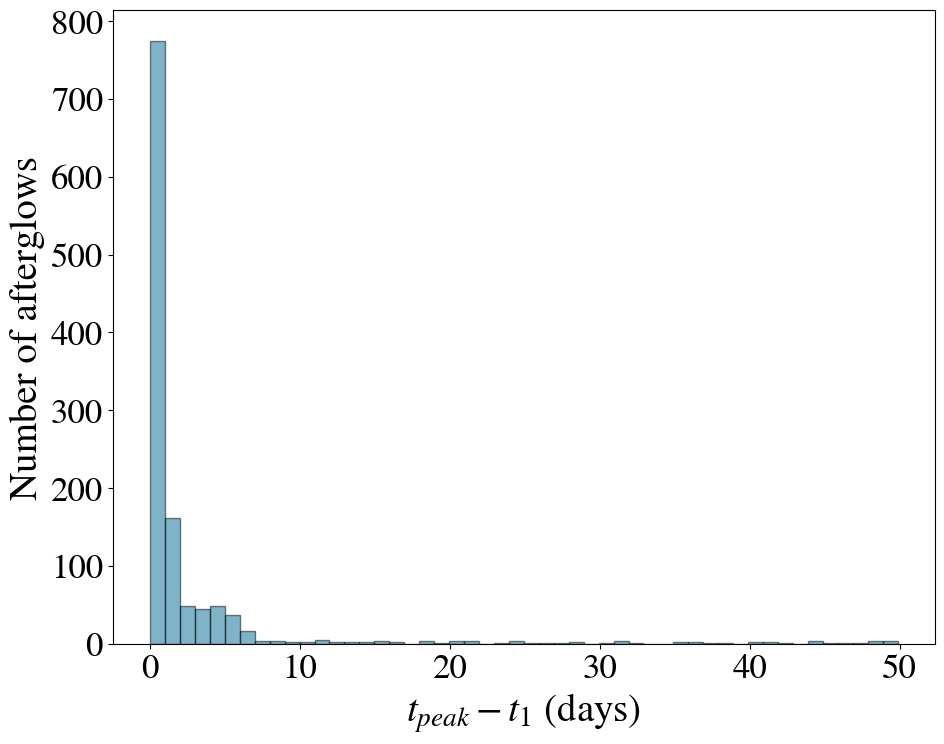

In [262]:
plt.rcParams.update({'font.size': 25})
plt.figure(figsize=(10, 8))

plt.hist(dt_po, bins=50, color='#006b93', alpha=0.5, edgecolor='black')
plt.xlabel("$t_{peak} - t_1$ (days)", fontsize=28)
plt.ylabel("Number of afterglows", fontsize=28)
#plt.axvline(x=15, lw=2, color="gray", ls='--', alpha=0.6)
#plt.text(17, 80, "15 days", rotation='vertical', fontsize=20, color='gray')

plt.tight_layout()

#plt.savefig("../../afterglowpy/figures/dt_features_ztf.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()

#### Rates

In [263]:
rate_i, rate_d1, rate_d3 = [], [], []

for i in range(len(df_orphans_ztf)):
    
    p = df_orphans_ztf.iloc[i]
    
    mask = np.array(p['mags'])<20.8
    times = np.array(p['time'])[mask]
    mags = np.array(p['mags'])[mask]
    filts = np.array(p['filt'])[mask]
    i, d1, d3 = compute_rates(times, mags, filts)
    rate_i.append(i) 
    rate_d1.append(d1) 
    rate_d3.append(d3)

/home/masson/afterglowpy/orphan_modules/features.py:72: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  time_f = times[np.where(filts == f)[0]]
/home/masson/afterglowpy/orphan_modules/features.py:73: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mag_f = mags[np.where(filts == f)[0]]


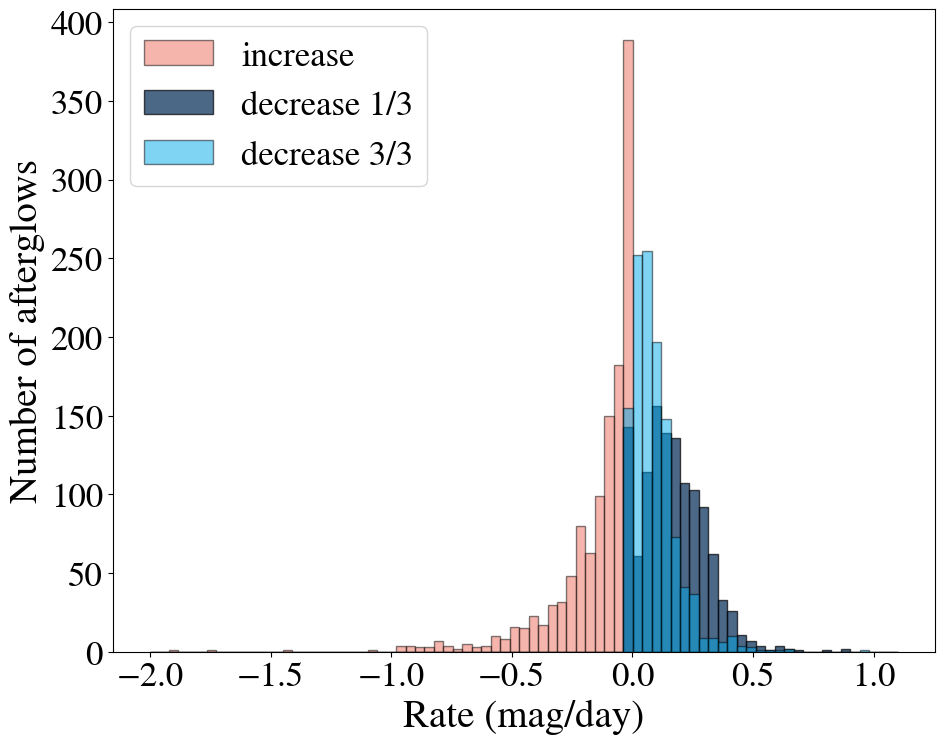

In [265]:
plt.rcParams.update({'font.size': 25})
plt.figure(figsize=(10, 8))

bin_edges = np.linspace(-2, 1.1, 80)

plt.hist(rate_i, bins=bin_edges, color='#ed6a5a', alpha=0.5, edgecolor='black', label = 'increase')
plt.hist(rate_d1, bins=bin_edges, color='#002855', alpha=0.7, edgecolor='black', label = 'decrease 1/3')
plt.hist(rate_d3, bins=bin_edges, color='#00a8e8', alpha=0.5, edgecolor='black', label = 'decrease 3/3')

plt.xlabel("Rate (mag/day)", fontsize=28)
plt.ylabel("Number of afterglows", fontsize=28)
#plt.xlim(-0.1, 0.3)
plt.legend()

plt.tight_layout()

#plt.savefig("../../afterglowpy/figures/rates_features_ztf.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()

#### Colours

In [266]:
colours = []

for i in range(len(df_orphans_ztf)):
    
    p = df_orphans_ztf.iloc[i]
    
    mask = np.array(p['mags'])<20.8
    times = np.array(p['time'])[mask]
    mags = np.array(p['mags'])[mask]
    filts = np.array(p['filt'])[mask]
    colours.append(compute_colours(times, mags, filts))

/home/masson/afterglowpy/orphan_modules/features.py:143: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  time_filter1 = times[np.where(filts == filter1)[0]]
/home/masson/afterglowpy/orphan_modules/features.py:144: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mag_filter1 = mags[np.where(filts == filter1)[0]]
/home/masson/afterglowpy/orphan_modules/features.py:146: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  time_filter2 = times[np.where(filts == filter2)[0]]
/home/masson/afterglowpy/orphan_modules/features.py:147: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mag_filter2 = mags[np.where(filts == filter2)[0]]


In [267]:
gr, ri = [], []
for pair in colours:
    gr.append(pair[0])
    ri.append(pair[1])

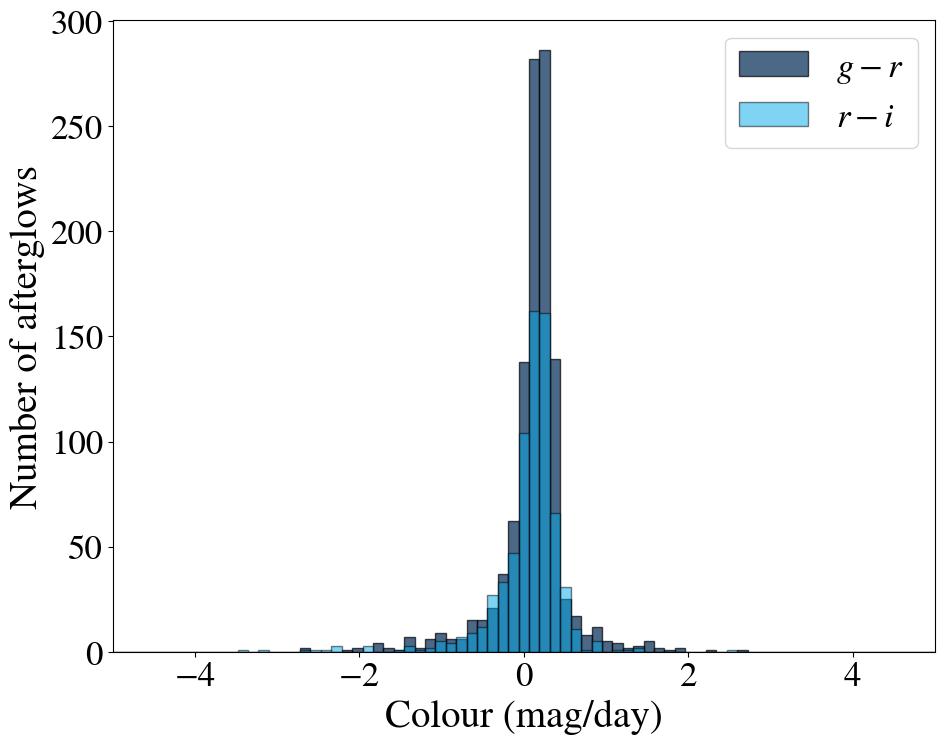

In [268]:
bin_edges = np.linspace(-5, 5, 80)

plt.rcParams.update({'font.size': 25})
plt.figure(figsize=(10, 8))

plt.hist(gr, bins=bin_edges, color='#002855', alpha=0.7, edgecolor='black', label = '$g-r$')
plt.hist(ri, bins=bin_edges, color='#00a8e8', alpha=0.5, edgecolor='black', label = '$r-i$')

plt.xlabel("Colour (mag/day)", fontsize=28)
plt.ylabel("Number of afterglows", fontsize=28)
plt.xlim(-5, 5)
plt.legend()

plt.tight_layout()
#plt.savefig("../../afterglowpy/figures/colour_features_ztf.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()

### Rescaling and fit

In [216]:
def rescale_filters(times, mags, mags_err, filts):
    """
    Calculate the rescaled magnitude to the r-band

    Parameters
    ----------
    times: list of float
        Concatenated times in MJD for the object
    mags: list of float
        Concatenated magnitudes for the object
    mags_err: list of float
        Concatenated magnitude errors for the object
    filts: list of float
        Concatenated filters for the object

    Returns
    -------
    time: array
        Array containing all the times of the rescaled points from 0 (0 being the time of the first alert)
    mag_r: array
        Array containing the rescaled magnitudes
    err: array
        Array containing the errors associated to the points
    """

    # mean frequencies for filters: g, r, i
    filters = ['g', 'r', 'i']
    mean_nu = [620752578941919.5, 463805775285244.6, 379313672969741.44]
    nu_dict = dict(zip(filters, mean_nu))

    # get r-band data
    is_r = filts == 'r'
    flux_r = mag_to_flux(mags[is_r])
    time_r = times[is_r]

    p = 2.2
    beta_range = np.linspace(-(p-1)/2, -p/2, 100)
    best_d = np.inf
    best_beta = None

    # choose the filter to rescale (with most data)
    filt_obs = filts[filts != 'r']
    if filt_obs.size > 0:
        unique, counts = np.unique(filt_obs, return_counts=True)
        filt_max = unique[np.argmax(counts)]
    else:
        filt_max = None

    if filt_max is not None:
        idx = filts == filt_max
        flux_filt = mag_to_flux(mags[idx])
        time_filt = times[idx]

        for b in beta_range:
            flux_rescaled = flux_filt * (nu_dict['r'] / nu_dict[filt_max]) ** b
            d = np.sum(np.sqrt((time_filt[:, np.newaxis] - time_r[np.newaxis, :])**2 +
                               (flux_rescaled[:, np.newaxis] - flux_r[np.newaxis, :])**2))
            if d < best_d:
                best_d = d
                best_beta = b

        # rescale all bands
        rescaled_flux = []
        rescaled_time = []
        rescaled_err = []

        for f in filters:
            idx = filts == f
            f_flux = mag_to_flux(mags[idx])
            f_time = times[idx]
            f_err = mags_err[idx]

            if f == 'r':
                rescaled_flux.append(f_flux)
            else:
                rescaled_flux.append(f_flux * (nu_dict['r'] / nu_dict[f]) ** best_beta)

            rescaled_time.append(f_time)
            rescaled_err.append(f_err)

        all_time = np.concatenate(rescaled_time)
        all_flux = np.concatenate(rescaled_flux)
        all_mags = flux_to_mag(all_flux)
        all_err = np.concatenate(rescaled_err)
        
        return all_time - min(all_time), all_mags, all_err

    else:

        return times - min(times), mags, mags_err


def model(t, params):
    """Function used to fit the light curve

    Parameters
    ----------
    t: list of float
        Concatenated time for the object
    params: tuple of float
        Parameters of the function, to estimate
    """

    A, B, C, D = params
    return A * t + B + C * np.exp(-D * t)


def fit_light_curve(times, mags, mags_err, filts):
    """
    Fit the light curve using an MCMC method

    Parameters
    ----------
    time: list of float
        Concatenated times in MJD for the object
    mags: list of float
        Concatenated magnitudes for the object
    err: list of float
        Concatenated magnitude errors for the object
    filt: list of float
        Concatenated filters for the object

    Returns
    -------
    A, B, C, D: float
        Parameters of the function to fit
    chi2: float
        Chi square calculated as chi2 = sum(((y - y_fit) / y_err)²)
    """

    t, y, yerr = rescale_filters(times, mags, mags_err, filts)

    least_squares = LeastSquares(t, y, yerr, model)

    initial = np.array([0.02, 20., 0., 1.5])
    m = Minuit(least_squares, initial, name=('A', 'B', 'C', 'D'))

    m.limits = [(-1e4, 1e4), (-1e6, 1e6), (-1e7, 1e7), (-0.03, 10.)]

    m.migrad()  # finds minimum of least_squares function
    m.hesse()  # accurately computes uncertainties

    n_try = 0
    while (m.fmin.reduced_chi2 > 3.):
        if (n_try < 10):
            n_try += 1
            initial += 0.5
            m = Minuit(least_squares, initial, name=('A', 'B', 'C', 'D'))

            m.limits = [(-1e4, 1e4), (-1e6, 1e6), (-1e7, 1e7), (-0.03, 10.)]

            m.migrad();  # finds minimum of least_squares function
            m.hesse();  # accurately computes uncertainties
        else:
            break

    A = m.values[0]
    B = m.values[1]
    C = m.values[2]
    D = m.values[3]
    chi2 = m.fmin.reduced_chi2

    return A, B, C, D, chi2

In [299]:
A, B, C, D = [], [], [], []
chi2 = []

for i in range(len(df_orphans_ztf)):
    
    p = df_orphans_ztf.iloc[i]
    
    mask = np.array(p['mags'])<20
    times = np.array(p['time'])[mask]
    mags = np.array(p['mags'])[mask]
    mags_err = np.array(p['mags_err'])[mask]
    filts = np.array(p['filt'])[mask]
    
    if times.size > 0:
        a, b, c, d, x2 = fit_light_curve(times, mags, mags_err, filts)
        A.append(a)
        B.append(b)
        C.append(c)
        D.append(d)
        chi2.append(x2)
        
    else:
        A.append(np.nan)
        B.append(np.nan)
        C.append(np.nan)
        D.append(np.nan)
        chi2.append(np.nan)

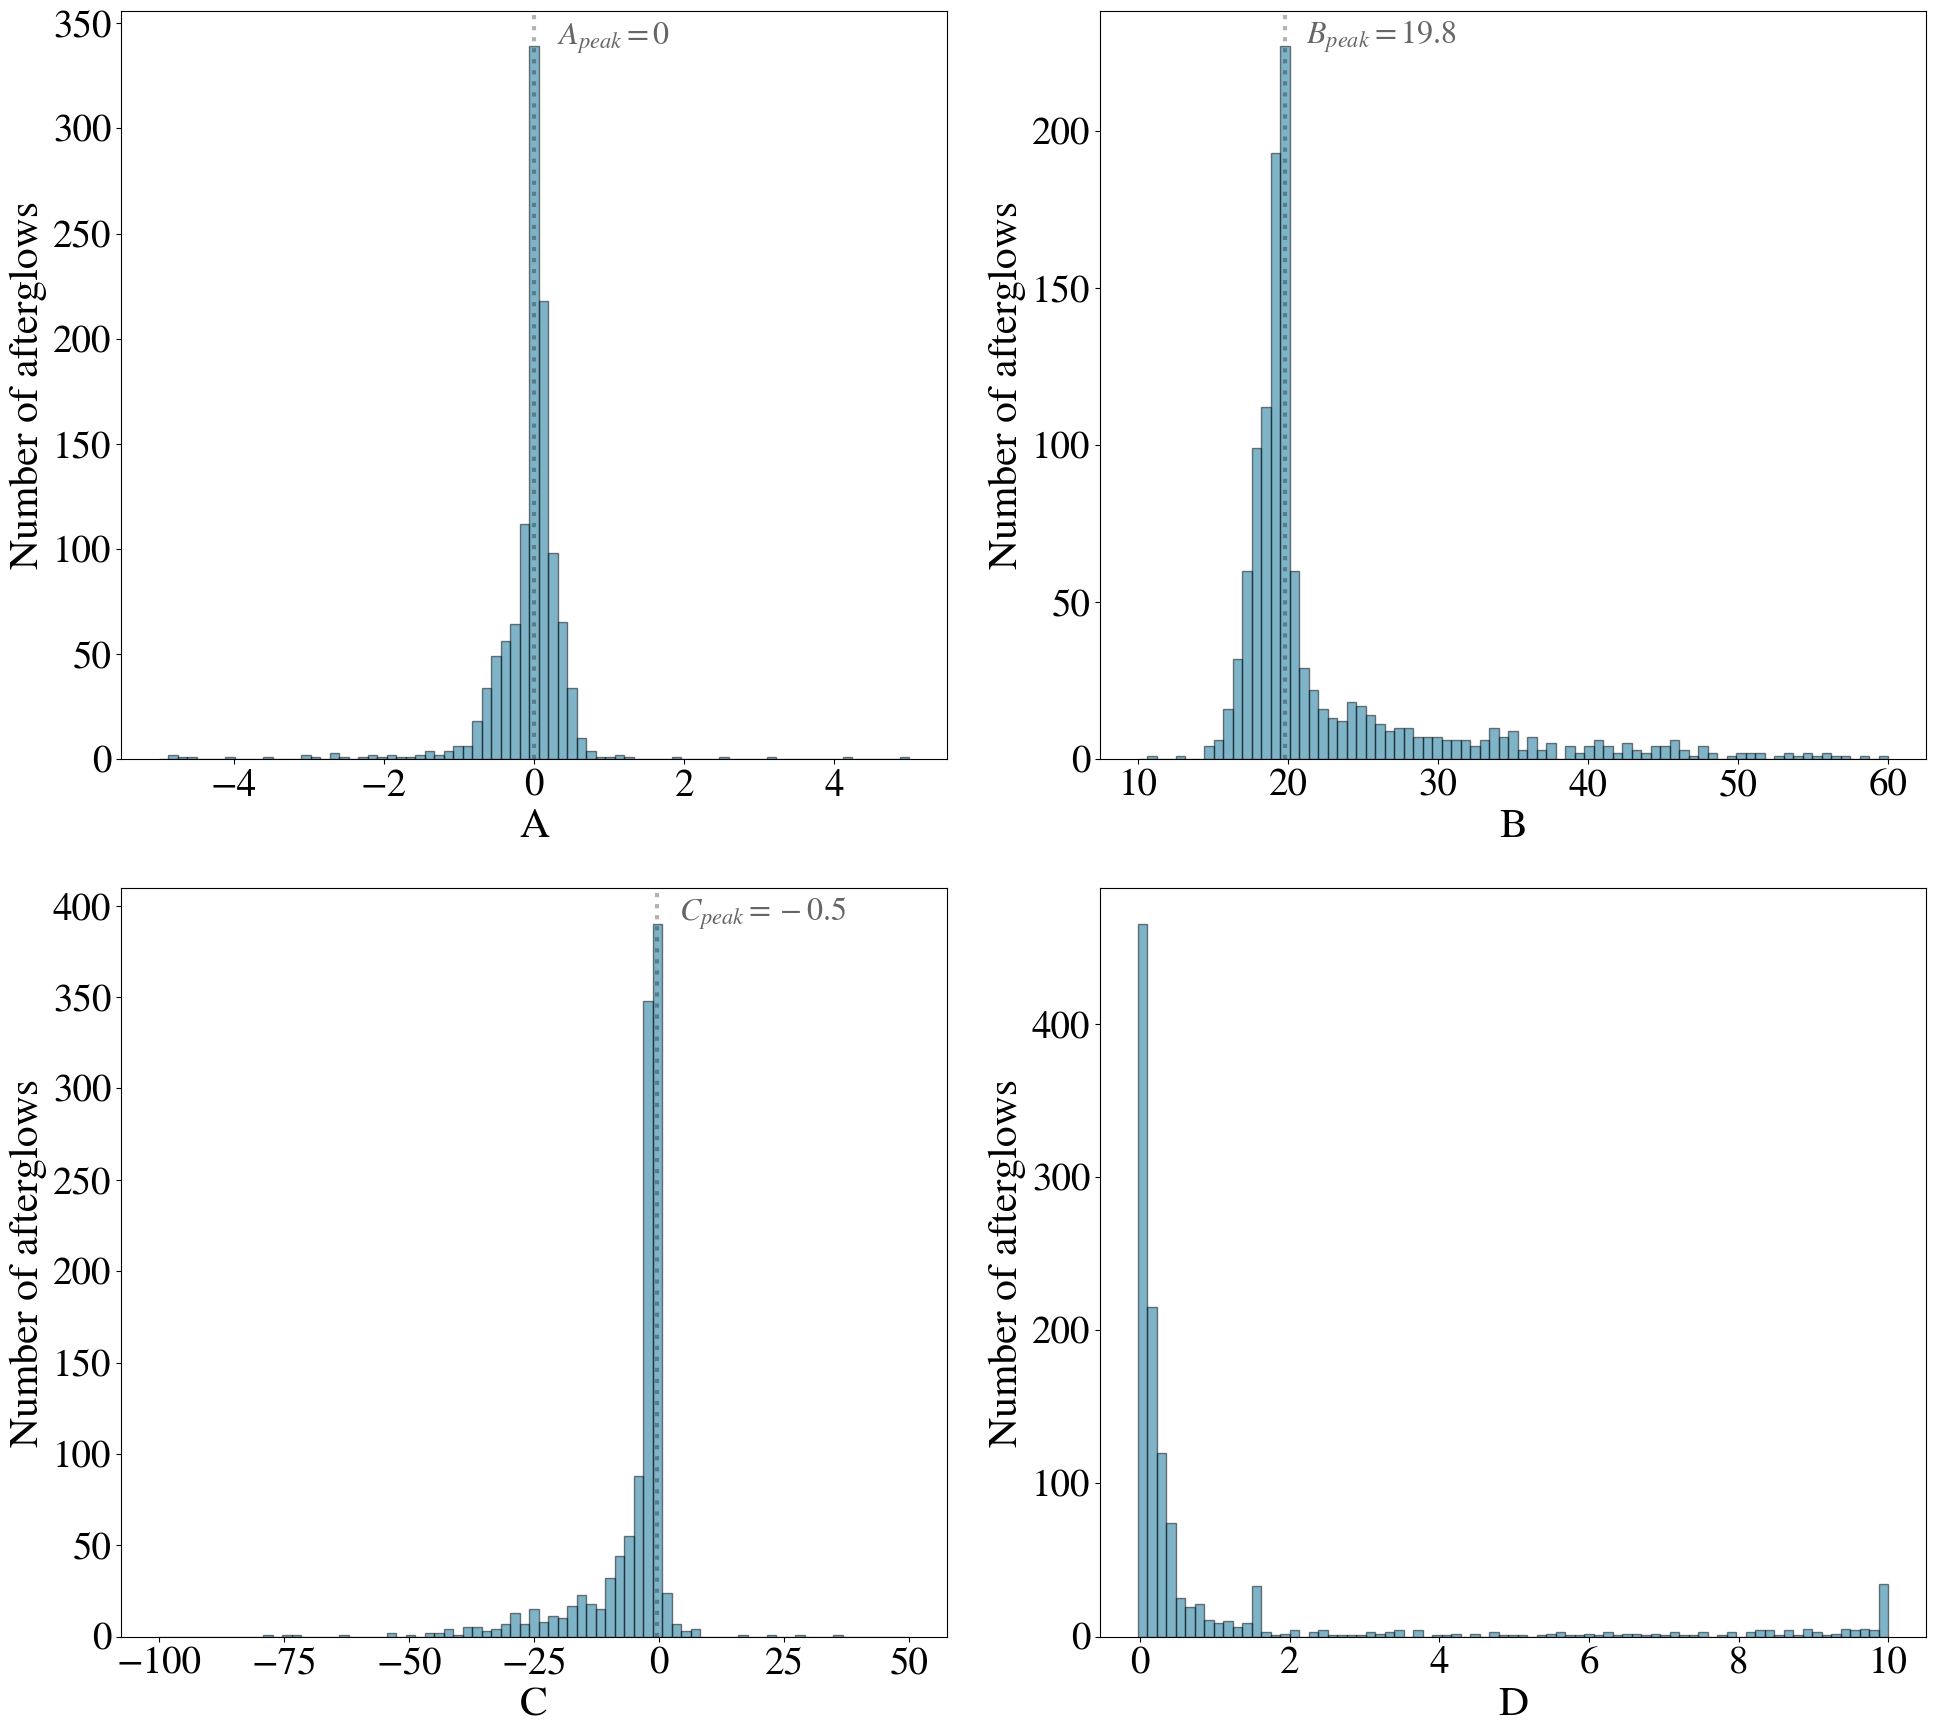

In [327]:
params = [A, B, C, D]
labels = ['A', 'B', 'C', 'D']

plt.rcParams.update({'font.size': 28})
fig, axes = plt.subplots(figsize=(20,18), nrows=2, ncols=2)

for i in range(4):
    
    ax = axes[i//2, i%2]
    
    if i==0:
        bin_edges = np.linspace(-5, 5, 80)
        ax.hist(params[i], bins=bin_edges, color='#006b93', alpha=0.5, edgecolor='black')
        ax.set_xlabel(labels[i], fontsize=30)
        ax.axvline(x=0, color='k', alpha=0.3, lw=3, ls=':')
        ax.text(0.3, 340, '$A_{peak}=0$', color='k', alpha=0.6, fontsize=23)
        
    elif i==1:      
        bin_edges = np.linspace(10, 60, 80)
        ax.hist(params[i], bins=bin_edges, color='#006b93', alpha=0.5, edgecolor='black')
        ax.set_xlabel(labels[i], fontsize=30)
        ax.axvline(x=19.8, color='k', alpha=0.3, lw=3, ls=':')
        ax.text(21.2, 228, '$B_{peak}=19.8$', color='k', alpha=0.6, fontsize=23)
        
    elif i==2:
        bin_edges = np.linspace(-100, 50, 80)
        ax.hist(params[i], bins=bin_edges, color='#006b93', alpha=0.5, edgecolor='black')
        ax.set_xlabel(labels[i], fontsize=30)
        ax.axvline(x=-0.5, color='k', alpha=0.3, lw=3, ls=':')
        ax.text(4, 392, '$C_{peak}=-0.5$', color='k', alpha=0.6, fontsize=23)
        
    elif i==3:
        bin_edges = np.linspace(-0.03, 10, 80)
        ax.hist(params[i], bins=bin_edges, color='#006b93', alpha=0.5, edgecolor='black')
        ax.set_xlabel(labels[i], fontsize=30)
    
    ax.set_ylabel('Number of afterglows', fontsize=30)
    #ax.set_xscale('log')
    #ax.set_ylim(30, 16)
    
plt.tight_layout() 

#plt.savefig('../../afterglowpy/figures/function_params_distrib_ztf.pdf', format="pdf", bbox_inches="tight", transparent=True)

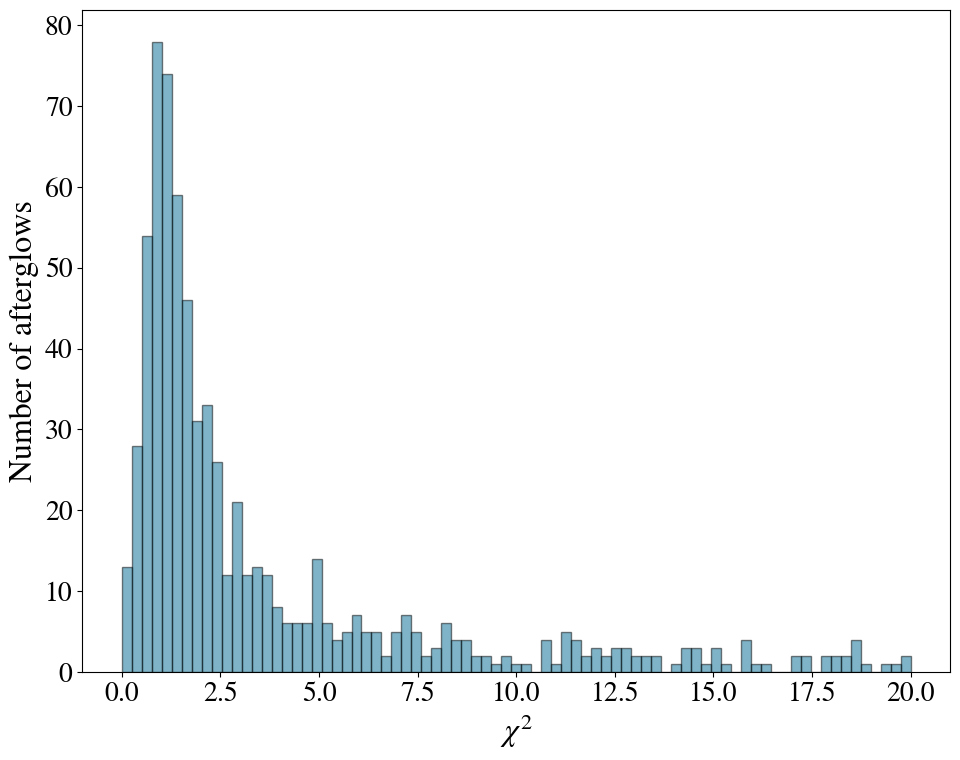

In [303]:
plt.rcParams.update({'font.size': 20})
plt.figure(figsize=(10, 8))

bin_edges = np.linspace(0., 20, 80)

plt.hist(chi2, bins=bin_edges, color='#006b93', alpha=0.5, edgecolor='black')
plt.xlabel("$\chi^2$", fontsize=23)
plt.ylabel("Number of afterglows", fontsize=23)

#plt.axvline(x=15, lw=2, color="gray", ls='--', alpha=0.6)
#plt.text(17, 80, "15 days", rotation='vertical', fontsize=20, color='gray')

plt.tight_layout()

plt.savefig("../../afterglowpy/figures/chi2_distrib_ztf.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()

In [220]:
df_orphans_ztf['duration'] = dt_po
df_orphans_ztf['increase_rate'] = rate_i
df_orphans_ztf['decrease_rate_1'] = rate_d1
df_orphans_ztf['decrease_rate_3'] = rate_d3
df_orphans_ztf['g-r'] = gr
df_orphans_ztf['r-i'] = ri
df_orphans_ztf['A'] = A
df_orphans_ztf['B'] = B
df_orphans_ztf['C'] = C
df_orphans_ztf['D'] = D
df_orphans_ztf['chi2'] = chi2
df_orphans_ztf['A/B'] = df_orphans_ztf['A']/df_orphans_ztf['B']

In [221]:
import pickle

file = open('/home/masson/orphans/data/pseudo_obs/orphan_pseudo_obs_features_ztf.pkl', 'wb')
pickle.dump(df_orphans_ztf, file)
file.close()

### Take a look at the fit

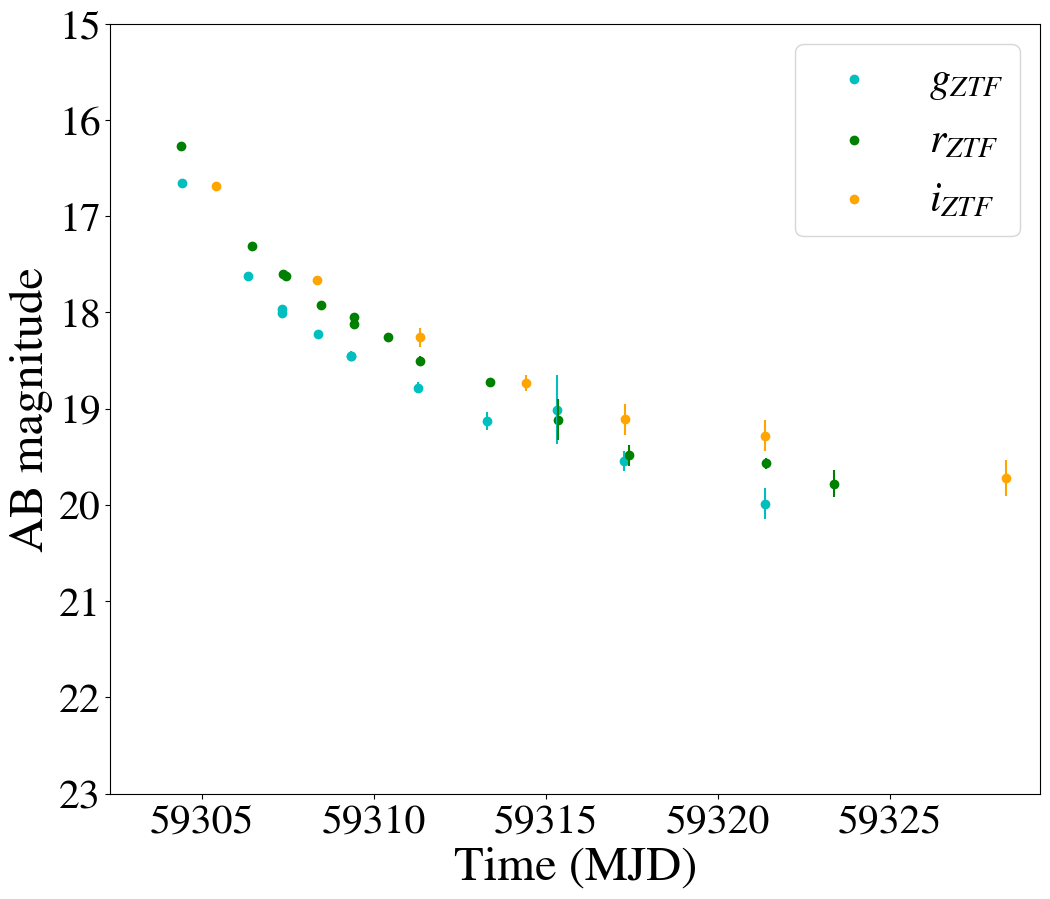

In [161]:
ztf_bands_label = ['$g_{ZTF}$', '$r_{ZTF}$', '$i_{ZTF}$']
ztf_bands = ['g', 'r', 'i']
band_colors = {'g':'c', 'r':'g', 'i':'orange'}

i = 9

time = np.array(df_orphans_ztf.iloc[i]['time'])
mags = np.array(df_orphans_ztf.iloc[i]['mags'])
mags_err = np.array(df_orphans_ztf.iloc[i]['mags_err'])
filts = np.array(df_orphans_ztf.iloc[i]['filt'])

plt.rcParams.update({'font.size': 30})
plt.figure(figsize=(12,10))

for b,l in zip(ztf_bands, ztf_bands_label):
    
    time_one_filt = time[filts == b]
    mags_one_filt = mags[filts == b]
    mags_err_one_filt = mags_err[filts == b]
    
    plt.errorbar(time_one_filt[mags_one_filt<20], mags_one_filt[mags_one_filt<20], 
                 mags_err_one_filt[mags_one_filt<20], color=band_colors[b], capsize=0, ls='')
    
    plt.scatter(time_one_filt[mags_one_filt<20], mags_one_filt[mags_one_filt<20], color=band_colors[b], label=l)

plt.xlabel('Time (MJD)', fontsize=35)
plt.ylabel('AB magnitude', fontsize=35)
plt.gca().invert_yaxis()
plt.ylim(23, 15)
plt.xlim(min(time)+4, max(time)-23)
plt.legend()

#plt.savefig("../../afterglowpy/figures/orphan_ztf_example_no_rescaling.pdf", format="pdf", bbox_inches="tight", transparent=True)

plt.show()

In [158]:
def rescale_filters(times, mags, mags_err, filts):
    """
    Calculate the rescaled magnitude to the r-band

    Parameters
    ----------
    times: list of float
        Concatenated times in MJD for the object
    mags: list of float
        Concatenated magnitudes for the object
    mags_err: list of float
        Concatenated magnitude errors for the object
    filts: list of float
        Concatenated filters for the object

    Returns
    -------
    time: array
        Array containing all the times of the rescaled points from 0 (0 being the time of the first alert)
    mag_r: array
        Array containing the rescaled magnitudes
    err: array
        Array containing the errors associated to the points
    """

    # mean frequencies for filters: g, r, i
    filters = ['g', 'r', 'i']
    mean_nu = [620752578941919.5, 463805775285244.6, 379313672969741.44]
    nu_dict = dict(zip(filters, mean_nu))

    # get r-band data
    is_r = filts == 'r'
    flux_r = mag_to_flux(mags[is_r])
    time_r = times[is_r]

    p = 2.2
    beta_range = np.linspace(-(p-1)/2, -p/2, 100)
    best_d = np.inf
    best_beta = None

    # choose the filter to rescale (with most data)
    filt_obs = filts[filts != 'r']
    if filt_obs.size > 0:
        unique, counts = np.unique(filt_obs, return_counts=True)
        filt_max = unique[np.argmax(counts)]
    else:
        filt_max = None

    if filt_max is not None:
        idx = filts == filt_max
        flux_filt = mag_to_flux(mags[idx])
        time_filt = times[idx]

        for b in beta_range:
            flux_rescaled = flux_filt * (nu_dict['r'] / nu_dict[filt_max]) ** b
            d = np.sum(np.sqrt((time_filt[:, np.newaxis] - time_r[np.newaxis, :])**2 +
                               (flux_rescaled[:, np.newaxis] - flux_r[np.newaxis, :])**2))
            if d < best_d:
                best_d = d
                best_beta = b

        # rescale all bands
        rescaled_flux = []
        rescaled_time = []
        rescaled_err = []

        for f in filters:
            idx = filts == f
            f_flux = mag_to_flux(mags[idx])
            f_time = times[idx]
            f_err = mags_err[idx]

            if f == 'r':
                rescaled_flux.append(f_flux)
            else:
                rescaled_flux.append(f_flux * (nu_dict['r'] / nu_dict[f]) ** best_beta)

            rescaled_time.append(f_time)
            rescaled_err.append(f_err)

        all_time = np.concatenate(rescaled_time)
        all_flux = np.concatenate(rescaled_flux)
        all_mags = flux_to_mag(all_flux)
        all_err = np.concatenate(rescaled_err)
        
        return all_time - min(all_time), all_mags, all_err

    else:

        return times - min(times), mags, mags_err


def model(t, params):
    """Function used to fit the light curve

    Parameters
    ----------
    t: list of float
        Concatenated time for the object
    params: tuple of float
        Parameters of the function, to estimate
    """

    A, B, C, D = params
    return A * t + B + C * np.exp(-D * t)


def fit_light_curve(times, mags, mags_err, filts):
    """
    Fit the light curve using an MCMC method

    Parameters
    ----------
    time: list of float
        Concatenated times in MJD for the object
    mags: list of float
        Concatenated magnitudes for the object
    err: list of float
        Concatenated magnitude errors for the object
    filt: list of float
        Concatenated filters for the object

    Returns
    -------
    A, B, C, D: float
        Parameters of the function to fit
    chi2: float
        Chi square calculated as chi2 = sum(((y - y_fit) / y_err)²)
    """

    t, y, yerr = rescale_filters(times, mags, mags_err, filts)

    least_squares = LeastSquares(t, y, yerr, model)

    initial = np.array([0.02, 20., 0., 1.5])
    m = Minuit(least_squares, initial, name=('A', 'B', 'C', 'D'))

    m.limits = [(-1e4, 1e4), (-1e6, 1e6), (-1e7, 1e7), (-0.03, 10.)]

    m.migrad()  # finds minimum of least_squares function
    m.hesse()  # accurately computes uncertainties

    A = m.values[0]
    B = m.values[1]
    C = m.values[2]
    D = m.values[3]
    chi2 = m.fmin.reduced_chi2

    return A, B, C, D, chi2

4.18869593275235
[0.09499448771711183, 17.98051926902133, -1.6892244771997866, 0.33356521024692504]


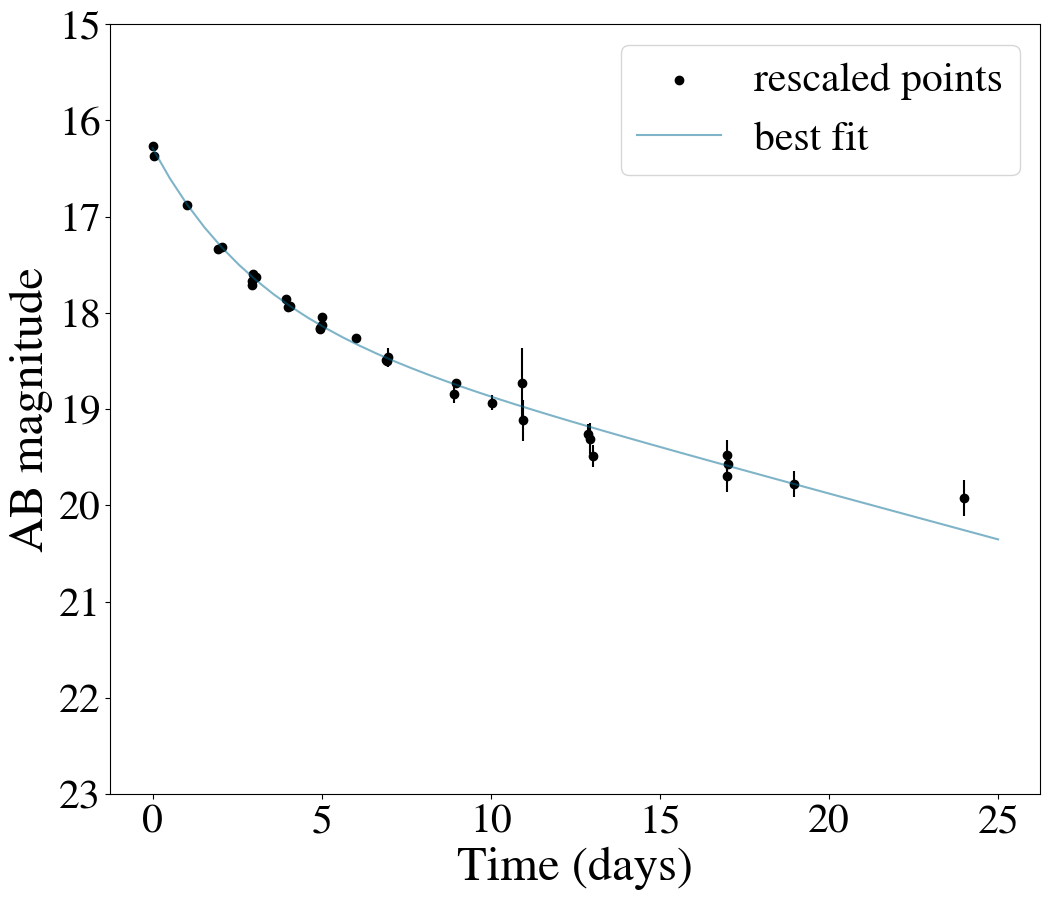

In [160]:
ztf_bands_label = ['$g_{ztf}$', '$r_{ztf}$', '$i_{ztf}$']
ztf_bands = ['g', 'r', 'i']
band_colors = {'g':'c', 'r':'g', 'i':'orange'}

plt.rcParams.update({'font.size': 30})
plt.figure(figsize=(12,10))

i = 9

time = np.array(df_orphans_ztf.iloc[i]['time'])
mags_all = np.array(df_orphans_ztf.iloc[i]['mags'])
mags_err = np.array(df_orphans_ztf.iloc[i]['mags_err'])
filts = np.array(df_orphans_ztf.iloc[i]['filt'])

mask = mags_all<20
times = time[mask]
mags = mags_all[mask]
mags_err = mags_err[mask]
filts = filts[mask]

t, y, yerr = rescale_filters(times, mags, mags_err, filts)
A, B, C, D, chi2 = fit_light_curve(times, mags, mags_err, filts)

print(chi2)
    
params = [A, B, C, D]
print(params)

t_fit = np.linspace(0, (max(t)-min(t))+1)
model_fit = model(t_fit, params)

plt.errorbar(t, y, yerr, color='k', capsize=0, ls='')
plt.scatter(t, y,  color='k', label='rescaled points')
plt.plot(t_fit, model_fit, color='#006b93', alpha=0.5, label='best fit')

plt.xlabel('Time (days)', fontsize=35)
plt.ylabel('AB magnitude', fontsize=35)
plt.gca().invert_yaxis()
plt.ylim(23, 15)
plt.legend()
#plt.xlim(min(time)-2, max(time)+2)

#plt.savefig("../../afterglowpy/figures/orphan_ztf_example_rescaling.pdf", format="pdf", bbox_inches="tight", transparent=True)

plt.show()

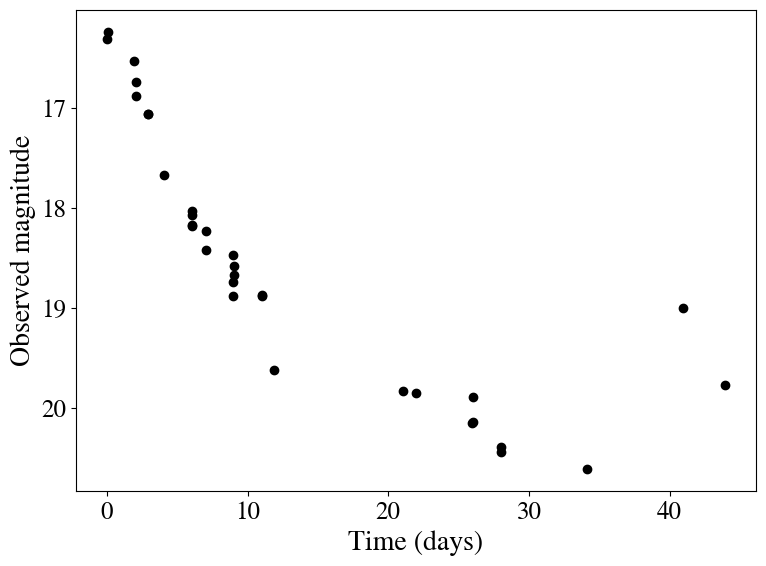

Best β = -0.600


In [232]:
plt.rcParams.update({'font.size': 18})

"""
time = np.array([59269.39, 59269.453, 59271.35, 59271.43, 59271.453, 59273.438, 59275.43,
                 59275.43, 59275.457, 59275.457, 59276.414, 59276.457, 59278.33, 59278.33,
                 59278.387, 59278.453, 59278.453, 59280.418, 59280.43, 59281.27, 59290.453,
                 59291.39, 59295.36, 59295.41, 59295.41, 59297.39, 59297.39, 59303.49,
                 59310.344, 59313.324, 59272.33, 59272.33])
mags = np.array([16.31537066, 16.43280984, 16.40601802, 17.07551489, 16.74202359, 17.86370471,
                 18.06750967, 18.02632189, 18.36068026, 18.37266168, 18.22860751, 18.6106699,
                 18.92414463, 19.07248792, 18.3364239, 18.67185602, 18.58018083, 19.05481525,
                 18.88038533, 19.6156007, 19.69722332, 19.84469583, 20.01439695, 19.88311841,
                 20.13047133, 20.38269871, 20.43302643, 20.47491113, 18.86682144, 19.6309381,
                 17.06285789, 17.05801425])
mags_err = np.array([0.0042902, 0.00882316, 0.00937975, 0.00880981, 0.00511906, 0.02977189,
                     0.02770152, 0.0114337, 0.0333165, 0.02406736, 0.02785416, 0.04509469,
                     0.01868372, 0.09134304, 0.07955981, 0.06059523, 0.05608579, 0.08904363,
                     0.07446794, 0.25708217, 0.15731329, 0.12057856, 0.2715179, 0.17546251,
                     0.18167414, 0.32834115, 0.23998774, 0.49370804, 0.89491561, 0.34146321,
                     0.03633209, 0.02315459])
filts = np.array(['r', 'g', 'i', 'g', 'r', 'g', 'r', 'r', 'g', 'g', 'r', 'g', 'g', 'g', 'i',
                  'r', 'r', 'g', 'r', 'r', 'i', 'r', 'i', 'r', 'r', 'r', 'r', 'i', 'i', 'i',
                  'r', 'r'])
"""

i = 4

time = np.array(df_orphans_ztf.iloc[i]['time'])
mags_all = np.array(df_orphans_ztf.iloc[i]['mags'])
mags_err = np.array(df_orphans_ztf.iloc[i]['mags_err'])
filts = np.array(df_orphans_ztf.iloc[i]['filt'])

mask = mags_all<20.5
time = time[mask]
mags = mags_all[mask]
mags_err = mags_err[mask]
filts = filts[mask]

# mean frequencies for ZTF filters
filters = ['g', 'r', 'i']
mean_nu = [620752578941919.5, 463805775285244.6, 379313672969741.44]
nu_dict = dict(zip(filters, mean_nu))


# get r-band data
is_r = filts == 'r'
flux_r = mag_to_flux(mags[is_r])
time_r = time[is_r]

p = 2.2
beta_range = np.linspace(-(p-1)/2, -p/2, 100)
best_d = np.inf
best_beta = None

# choose the filter to rescale (with most data)
filt_obs = filts[filts != 'r']
if filt_obs.size > 0:
    unique, counts = np.unique(filt_obs, return_counts=True)
    filt_max = unique[np.argmax(counts)]
else:
    filt_max = None

if filt_max is not None:
    idx = filts == filt_max
    flux_filt = mag_to_flux(mags[idx])
    time_filt = time[idx]

    for b in beta_range:
        flux_rescaled = flux_filt * (nu_dict['r'] / nu_dict[filt_max]) ** b
        d = np.sum(np.sqrt((time_filt[:, np.newaxis] - time_r[np.newaxis, :])**2 +
                           (flux_rescaled[:, np.newaxis] - flux_r[np.newaxis, :])**2))
        if d < best_d:
            best_d = d
            best_beta = b

    # rescale all bands
    rescaled_flux = []
    rescaled_time = []
    rescaled_err = []

    for f in filters:
        idx = filts == f
        f_flux = mag_to_flux(mags[idx])
        f_time = time[idx]
        f_err = mags_err[idx]

        if f == 'r':
            rescaled_flux.append(f_flux)
        else:
            rescaled_flux.append(f_flux * (nu_dict['r'] / nu_dict[f]) ** best_beta)

        rescaled_time.append(f_time)
        rescaled_err.append(f_err)

    all_time = np.concatenate(rescaled_time)
    all_flux = np.concatenate(rescaled_flux)
    all_mags = flux_to_mag(all_flux)
    all_err = np.concatenate(rescaled_err)

    plt.figure(figsize=(8, 6))
    plt.scatter(all_time - min(all_time), all_mags, color='k')
    plt.gca().invert_yaxis()
    plt.xlabel("Time (days)", fontsize=20)
    plt.ylabel("Observed magnitude", fontsize=20)
    plt.tight_layout()
    plt.show()

    print(f"Best β = {best_beta:.3f}")

else:
    print("No non-r filters found to rescale.")


## ZTF alerts

ZTF data downloaded from the Fink Data Transfer for the months of May and June (2 months).

Criteria: mag<20.5 and at least 5 detections

In [164]:
import os
dir_class = [x[0] for x in os.walk('/home/masson/ftransfer_ztf_2025-07-08_196630')]

In [165]:
dir_class

['/home/masson/ftransfer_ztf_2025-07-08_196630',
 '/home/masson/ftransfer_ztf_2025-07-08_196630/finkclass=SN%20candidate',
 '/home/masson/ftransfer_ztf_2025-07-08_196630/finkclass=Supernova',
 '/home/masson/ftransfer_ztf_2025-07-08_196630/finkclass=EmissionG',
 '/home/masson/ftransfer_ztf_2025-07-08_196630/finkclass=Early%20SN%20Ia%20candidate',
 '/home/masson/ftransfer_ztf_2025-07-08_196630/finkclass=Seyfert1',
 '/home/masson/ftransfer_ztf_2025-07-08_196630/finkclass=Unknown',
 '/home/masson/ftransfer_ztf_2025-07-08_196630/finkclass=GtowardsGroup',
 '/home/masson/ftransfer_ztf_2025-07-08_196630/finkclass=Microlensing%20candidate',
 '/home/masson/ftransfer_ztf_2025-07-08_196630/finkclass=Ambiguous',
 '/home/masson/ftransfer_ztf_2025-07-08_196630/finkclass=Mira',
 '/home/masson/ftransfer_ztf_2025-07-08_196630/finkclass=Kilonova%20candidate',
 '/home/masson/ftransfer_ztf_2025-07-08_196630/finkclass=AGN_Candidate',
 '/home/masson/ftransfer_ztf_2025-07-08_196630/finkclass=RadioG',
 '/home/

In [167]:
from pathlib import Path
import pandas as pd

full_df = []

for d in dir_class[1:]:
    data_dir = Path(d)
    full_df.append(pd.concat(pd.read_parquet(parquet_file) for parquet_file in data_dir.glob('*.parquet')))

In [168]:
len(full_df)

22

In [169]:
df_ztf = pd.concat(x for x in full_df)

In [170]:
df_ztf

,magpsf,jd,objectId,sigmapsf,fid
0,18.866375,2.460821e+06,ZTF25aaqemjr,0.102492,1
1,18.316223,2.460821e+06,ZTF25aaqomig,0.068903,1
2,18.848528,2.460821e+06,ZTF25aarvkyy,0.085159,2
3,19.549109,2.460821e+06,ZTF25aankpyy,0.113318,2
4,20.344917,2.460821e+06,ZTF25aamaffc,0.179209,1
...,...,...,...,...,...
0,19.094116,2.460798e+06,ZTF19aauoiow,0.123643,2
0,19.088820,2.460799e+06,ZTF19aauoiow,0.118091,2
1,19.273003,2.460799e+06,ZTF19aauoiow,0.150844,2
0,19.086140,2.460799e+06,ZTF19aauoiow,0.112620,2


In [171]:
objectId = list(df_ztf['objectId'])
objectId = list(set(objectId))

In [173]:
len(objectId)

2621

In [106]:
mags = []
time = []
mags_err = []
filt = []

for objid in objectId:
    
    obj = df_ztf[df_ztf['objectId']==objid]
    
    mags.append(np.array(obj['magpsf']))
    time.append(np.array(obj['jd']))
    mags_err.append(np.array(obj['sigmapsf']))
    filt.append(np.array(obj['fid']))

In [107]:
data_dic = {'obj': objectId, 
            'time': time, 
            'mags': mags, 
            'mags_err': mags_err, 
            'filt': filt}

In [108]:
lc_ztf = pd.DataFrame(data=data_dic)

In [109]:
lc_ztf

,obj,time,mags,mags_err,filt
0,ZTF25aamajdl,[2460796.9116898],[20.269441604614258],[0.19332075119018555],[2]
1,ZTF25aaqkrze,"[2460820.9389005, 2460820.891956, 2460826.9020...","[18.816198348999023, 18.937110900878906, 19.03...","[0.06286535412073135, 0.06951691955327988, 0.1...","[2, 1, 1, 1, 2, 2, 2, 2, 1, 2, 1, 1, 1, 2, 1, ..."
2,ZTF25aaqemtu,"[2460817.8029977, 2460814.7914352, 2460821.773...","[19.547832489013672, 19.639507293701172, 19.32...","[0.11139839142560959, 0.2130787968635559, 0.11...","[1, 1, 1, 1, 1, 1]"
3,ZTF25aawzvdi,"[2460854.9709838, 2460855.9703704]","[19.764820098876953, 19.925783157348633]","[0.20599813759326935, 0.18434323370456696]","[2, 2]"
4,ZTF25aaqrolj,[2460823.7274306],[19.83783721923828],[0.20722562074661255],[2]
...,...,...,...,...,...
2616,ZTF25aatnkyr,"[2460834.8807176, 2460832.9231366, 2460832.915...","[18.582515716552734, 17.462373733520508, 17.25...","[0.10426966100931168, 0.04357177019119263, 0.0...","[1, 2, 1, 2]"
2617,ZTF25aavhnve,"[2460848.7946528, 2460847.8188194, 2460848.836...","[19.16620445251465, 19.065298080444336, 19.239...","[0.08856041729450226, 0.11144764721393585, 0.0...","[2, 2, 1, 1, 2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 1, ..."
2618,ZTF25aanoxjb,[2460796.7620486],[20.01392364501953],[0.1862446814775467],[2]
2619,ZTF25aavghwt,[2460842.7006829],[20.313425064086914],[0.19414649903774261],[2]


In [ ]:
file_open = open(f'/home/masson/orphans/data/ztf_alerts_lc.pkl', 'rb')
lc_ztf = pickle.load(file_open)
file_open.close()

In [8]:
lc_ztf = lc_ztf[lc_ztf["mags"].apply(len) > 4]

### Straightforward features

In [9]:
dt_po = []

for i in range(len(lc_ztf)):
    
    p = lc_ztf.iloc[i]
    
    mask = np.array(p['mags'])<20.8
    times = np.array(p['time'])[mask]
    mags = np.array(p['mags'])[mask]
    dt_po.append(compute_duration_between_first_and_peak(times, mags))

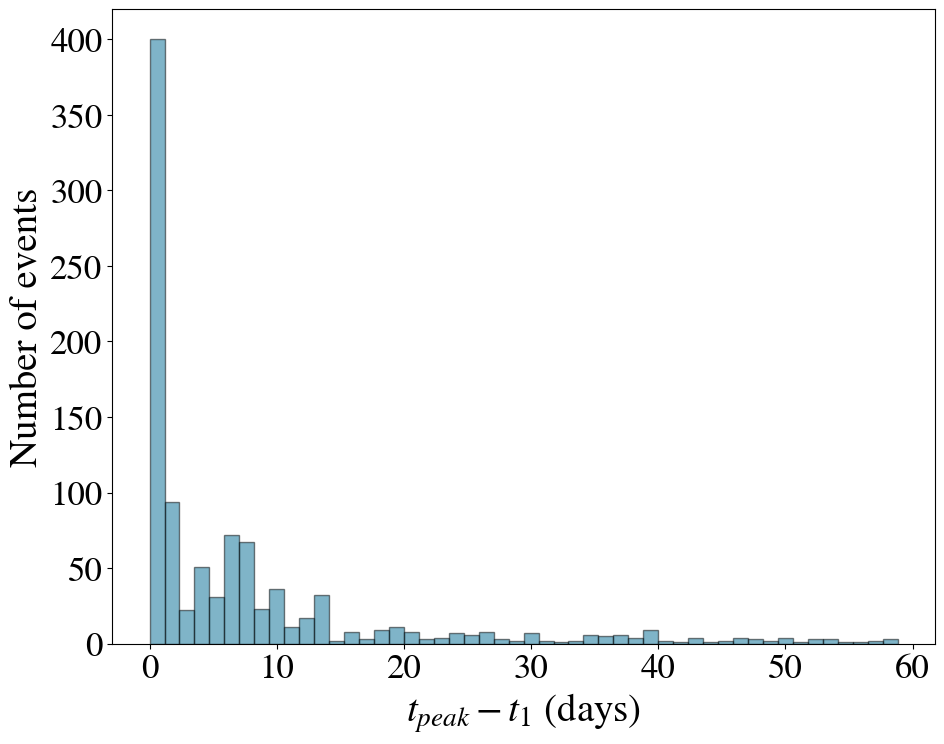

In [10]:
plt.rcParams.update({'font.size': 25})
plt.figure(figsize=(10, 8))

plt.hist(dt_po, bins=50, color='#006b93', alpha=0.5, edgecolor='black')
plt.xlabel("$t_{peak} - t_1$ (days)", fontsize=28)
plt.ylabel("Number of events", fontsize=28)

plt.tight_layout()

#plt.savefig("../../afterglowpy/figures/dt_features_ztf_alerts.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()

In [11]:
rate_i, rate_d1, rate_d3 = [], [], []

for i in range(len(lc_ztf)):
    
    p = lc_ztf.iloc[i]
    
    mask = np.array(p['mags'])<20.8
    times = np.array(p['time'])[mask]
    mags = np.array(p['mags'])[mask]
    filts = np.array(p['filt'])[mask]
    i, d1, d3 = compute_rates(times, mags, filts)
    rate_i.append(i) 
    rate_d1.append(d1) 
    rate_d3.append(d3)

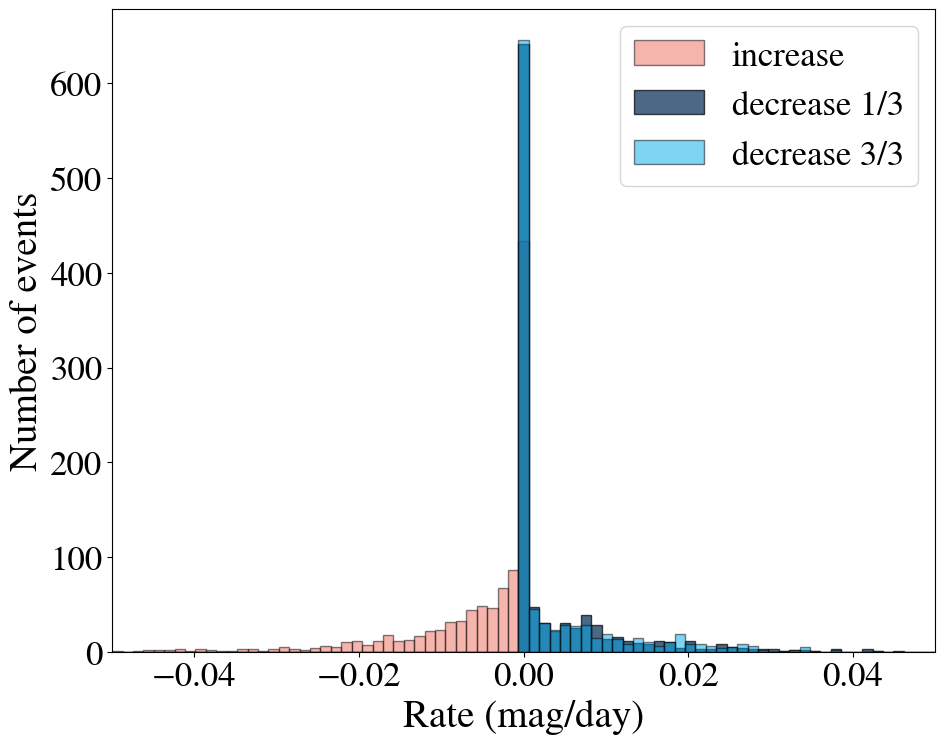

In [12]:
plt.rcParams.update({'font.size': 25})
plt.figure(figsize=(10, 8))

bin_edges = np.linspace(-0.05, 0.05, 80)

plt.hist(rate_i, bins=bin_edges, color='#ed6a5a', alpha=0.5, edgecolor='black', label = 'increase')
plt.hist(rate_d1, bins=bin_edges, color='#002855', alpha=0.7, edgecolor='black', label = 'decrease 1/3')
plt.hist(rate_d3, bins=bin_edges, color='#00a8e8', alpha=0.5, edgecolor='black', label = 'decrease 3/3')

plt.xlabel("Rate (mag/day)", fontsize=28)
plt.ylabel("Number of events", fontsize=28)
plt.xlim(-0.05, 0.05)
plt.legend()

plt.tight_layout()

#plt.savefig("../../afterglowpy/figures/rates_features_ztf_alerts.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()

In [13]:
colours = []

for i in range(len(lc_ztf)):
    
    p = lc_ztf.iloc[i]
    
    mask = np.array(p['mags'])<20.8
    times = np.array(p['time'])[mask]
    mags = np.array(p['mags'])[mask]
    filts = np.array(p['filt'])[mask]
    colours.append(compute_colours(times, mags, filts))

In [14]:
gr, ri = [], []
for pair in colours:
    gr.append(pair[0])
    ri.append(pair[1])

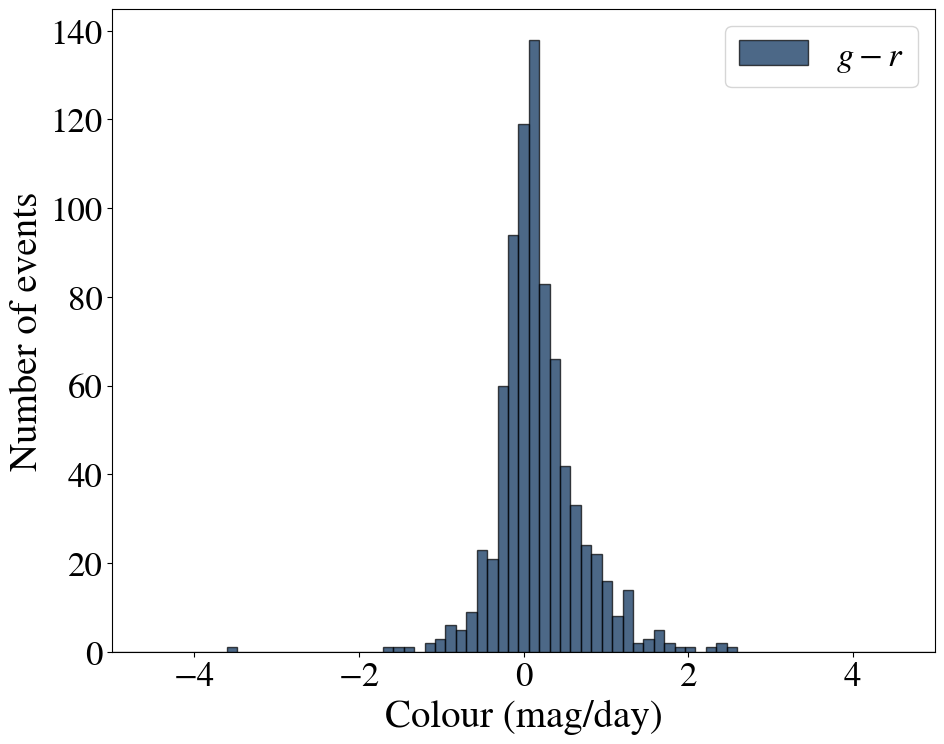

In [62]:
bin_edges = np.linspace(-5, 5, 80)

plt.rcParams.update({'font.size': 25})
plt.figure(figsize=(10, 8))

plt.hist(gr, bins=bin_edges, color='#002855', alpha=0.7, edgecolor='black', label = '$g-r$')
#plt.hist(ri, bins=bin_edges, color='#00a8e8', alpha=0.5, edgecolor='black', label = '$r-i$')

plt.xlabel("Colour (mag/day)", fontsize=28)
plt.ylabel("Number of events", fontsize=28)
plt.xlim(-5, 5)
plt.legend()

plt.tight_layout()
#plt.savefig("../../afterglowpy/figures/colour_features_ztf_alerts.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()

### Rescaling and fit

In [8]:
def rescale_filters(times, mags, mags_err, filts):
    """
    Calculate the rescaled magnitude to the r-band

    Parameters
    ----------
    times: list of float
        Concatenated times in MJD for the object
    mags: list of float
        Concatenated magnitudes for the object
    mags_err: list of float
        Concatenated magnitude errors for the object
    filts: list of float
        Concatenated filters for the object

    Returns
    -------
    time: array
        Array containing all the times of the rescaled points from 0 (0 being the time of the first alert)
    mag_r: array
        Array containing the rescaled magnitudes
    err: array
        Array containing the errors associated to the points
    """

    # mean frequencies for filters: g, r, i
    filters = ['g', 'r', 'i']
    mean_nu = [620752578941919.5, 463805775285244.6, 379313672969741.44]
    nu_dict = dict(zip(filters, mean_nu))

    # get r-band data
    is_r = filts == 'r'
    flux_r = mag_to_flux(mags[is_r])
    time_r = times[is_r]

    p = 2.2
    beta_range = np.linspace(-(p-1)/2, -p/2, 100)
    best_d = np.inf
    best_beta = None

    # choose the filter to rescale (with most data)
    filt_obs = filts[filts != 'r']
    if filt_obs.size > 0:
        unique, counts = np.unique(filt_obs, return_counts=True)
        filt_max = unique[np.argmax(counts)]
    else:
        filt_max = None

    if filt_max is not None:
        idx = filts == filt_max
        flux_filt = mag_to_flux(mags[idx])
        time_filt = times[idx]

        for b in beta_range:
            flux_rescaled = flux_filt * (nu_dict['r'] / nu_dict[filt_max]) ** b
            d = np.sum(np.sqrt((time_filt[:, np.newaxis] - time_r[np.newaxis, :])**2 +
                               (flux_rescaled[:, np.newaxis] - flux_r[np.newaxis, :])**2))
            if d < best_d:
                best_d = d
                best_beta = b

        # rescale all bands
        rescaled_flux = []
        rescaled_time = []
        rescaled_err = []

        for f in filters:
            idx = filts == f
            f_flux = mag_to_flux(mags[idx])
            f_time = times[idx]
            f_err = mags_err[idx]

            if f == 'r':
                rescaled_flux.append(f_flux)
            else:
                rescaled_flux.append(f_flux * (nu_dict['r'] / nu_dict[f]) ** best_beta)

            rescaled_time.append(f_time)
            rescaled_err.append(f_err)

        all_time = np.concatenate(rescaled_time)
        all_flux = np.concatenate(rescaled_flux)
        all_mags = flux_to_mag(all_flux)
        all_err = np.concatenate(rescaled_err)
        
        return all_time - min(all_time), all_mags, all_err

    else:

        return times - min(times), mags, mags_err


def model(t, params):
    """Function used to fit the light curve

    Parameters
    ----------
    t: list of float
        Concatenated time for the object
    params: tuple of float
        Parameters of the function, to estimate
    """

    A, B, C, D = params
    return A * t + B + C * np.exp(-D * t)


def fit_light_curve(times, mags, mags_err, filts):
    """
    Fit the light curve using an MCMC method

    Parameters
    ----------
    time: list of float
        Concatenated times in MJD for the object
    mags: list of float
        Concatenated magnitudes for the object
    err: list of float
        Concatenated magnitude errors for the object
    filt: list of float
        Concatenated filters for the object

    Returns
    -------
    A, B, C, D: float
        Parameters of the function to fit
    chi2: float
        Chi square calculated as chi2 = sum(((y - y_fit) / y_err)²)
    """

    t, y, yerr = rescale_filters(times, mags, mags_err, filts)

    least_squares = LeastSquares(t, y, yerr, model)

    initial = np.array([0.02, 20., 0., 1.5])
    m = Minuit(least_squares, initial, name=('A', 'B', 'C', 'D'))

    m.limits = [(-1e4, 1e4), (-1e6, 1e6), (-1e7, 1e7), (-0.03, 10.)]

    m.migrad()  # finds minimum of least_squares function
    m.hesse()  # accurately computes uncertainties

    n_try = 0
    while (m.fmin.reduced_chi2 > 3.):
        if (n_try < 10):
            n_try += 1
            initial += 0.5
            m = Minuit(least_squares, initial, name=('A', 'B', 'C', 'D'))

            m.limits = [(-1e4, 1e4), (-1e6, 1e6), (-1e7, 1e7), (-0.03, 10.)]

            m.migrad();  # finds minimum of least_squares function
            m.hesse();  # accurately computes uncertainties
        else:
            break

    A = m.values[0]
    B = m.values[1]
    C = m.values[2]
    D = m.values[3]
    chi2 = m.fmin.reduced_chi2

    return A, B, C, D, chi2

In [18]:
A, B, C, D = [], [], [], []
chi2 = []

for i in range(len(lc_ztf)):
    
    p = lc_ztf.iloc[i]
    
    mask = np.array(p['mags'])<20
    times = np.array(p['time'])[mask]
    mags = np.array(p['mags'])[mask]
    mags_err = np.array(p['mags_err'])[mask]
    filts = np.array(p['filt'])[mask]
    
    if times.size > 0:
        a, b, c, d, x2 = fit_light_curve(times, mags, mags_err, filts)
        A.append(a)
        B.append(b)
        C.append(c)
        D.append(d)
        chi2.append(x2)
        
    else:
        A.append(np.nan)
        B.append(np.nan)
        C.append(np.nan)
        D.append(np.nan)
        chi2.append(np.nan)

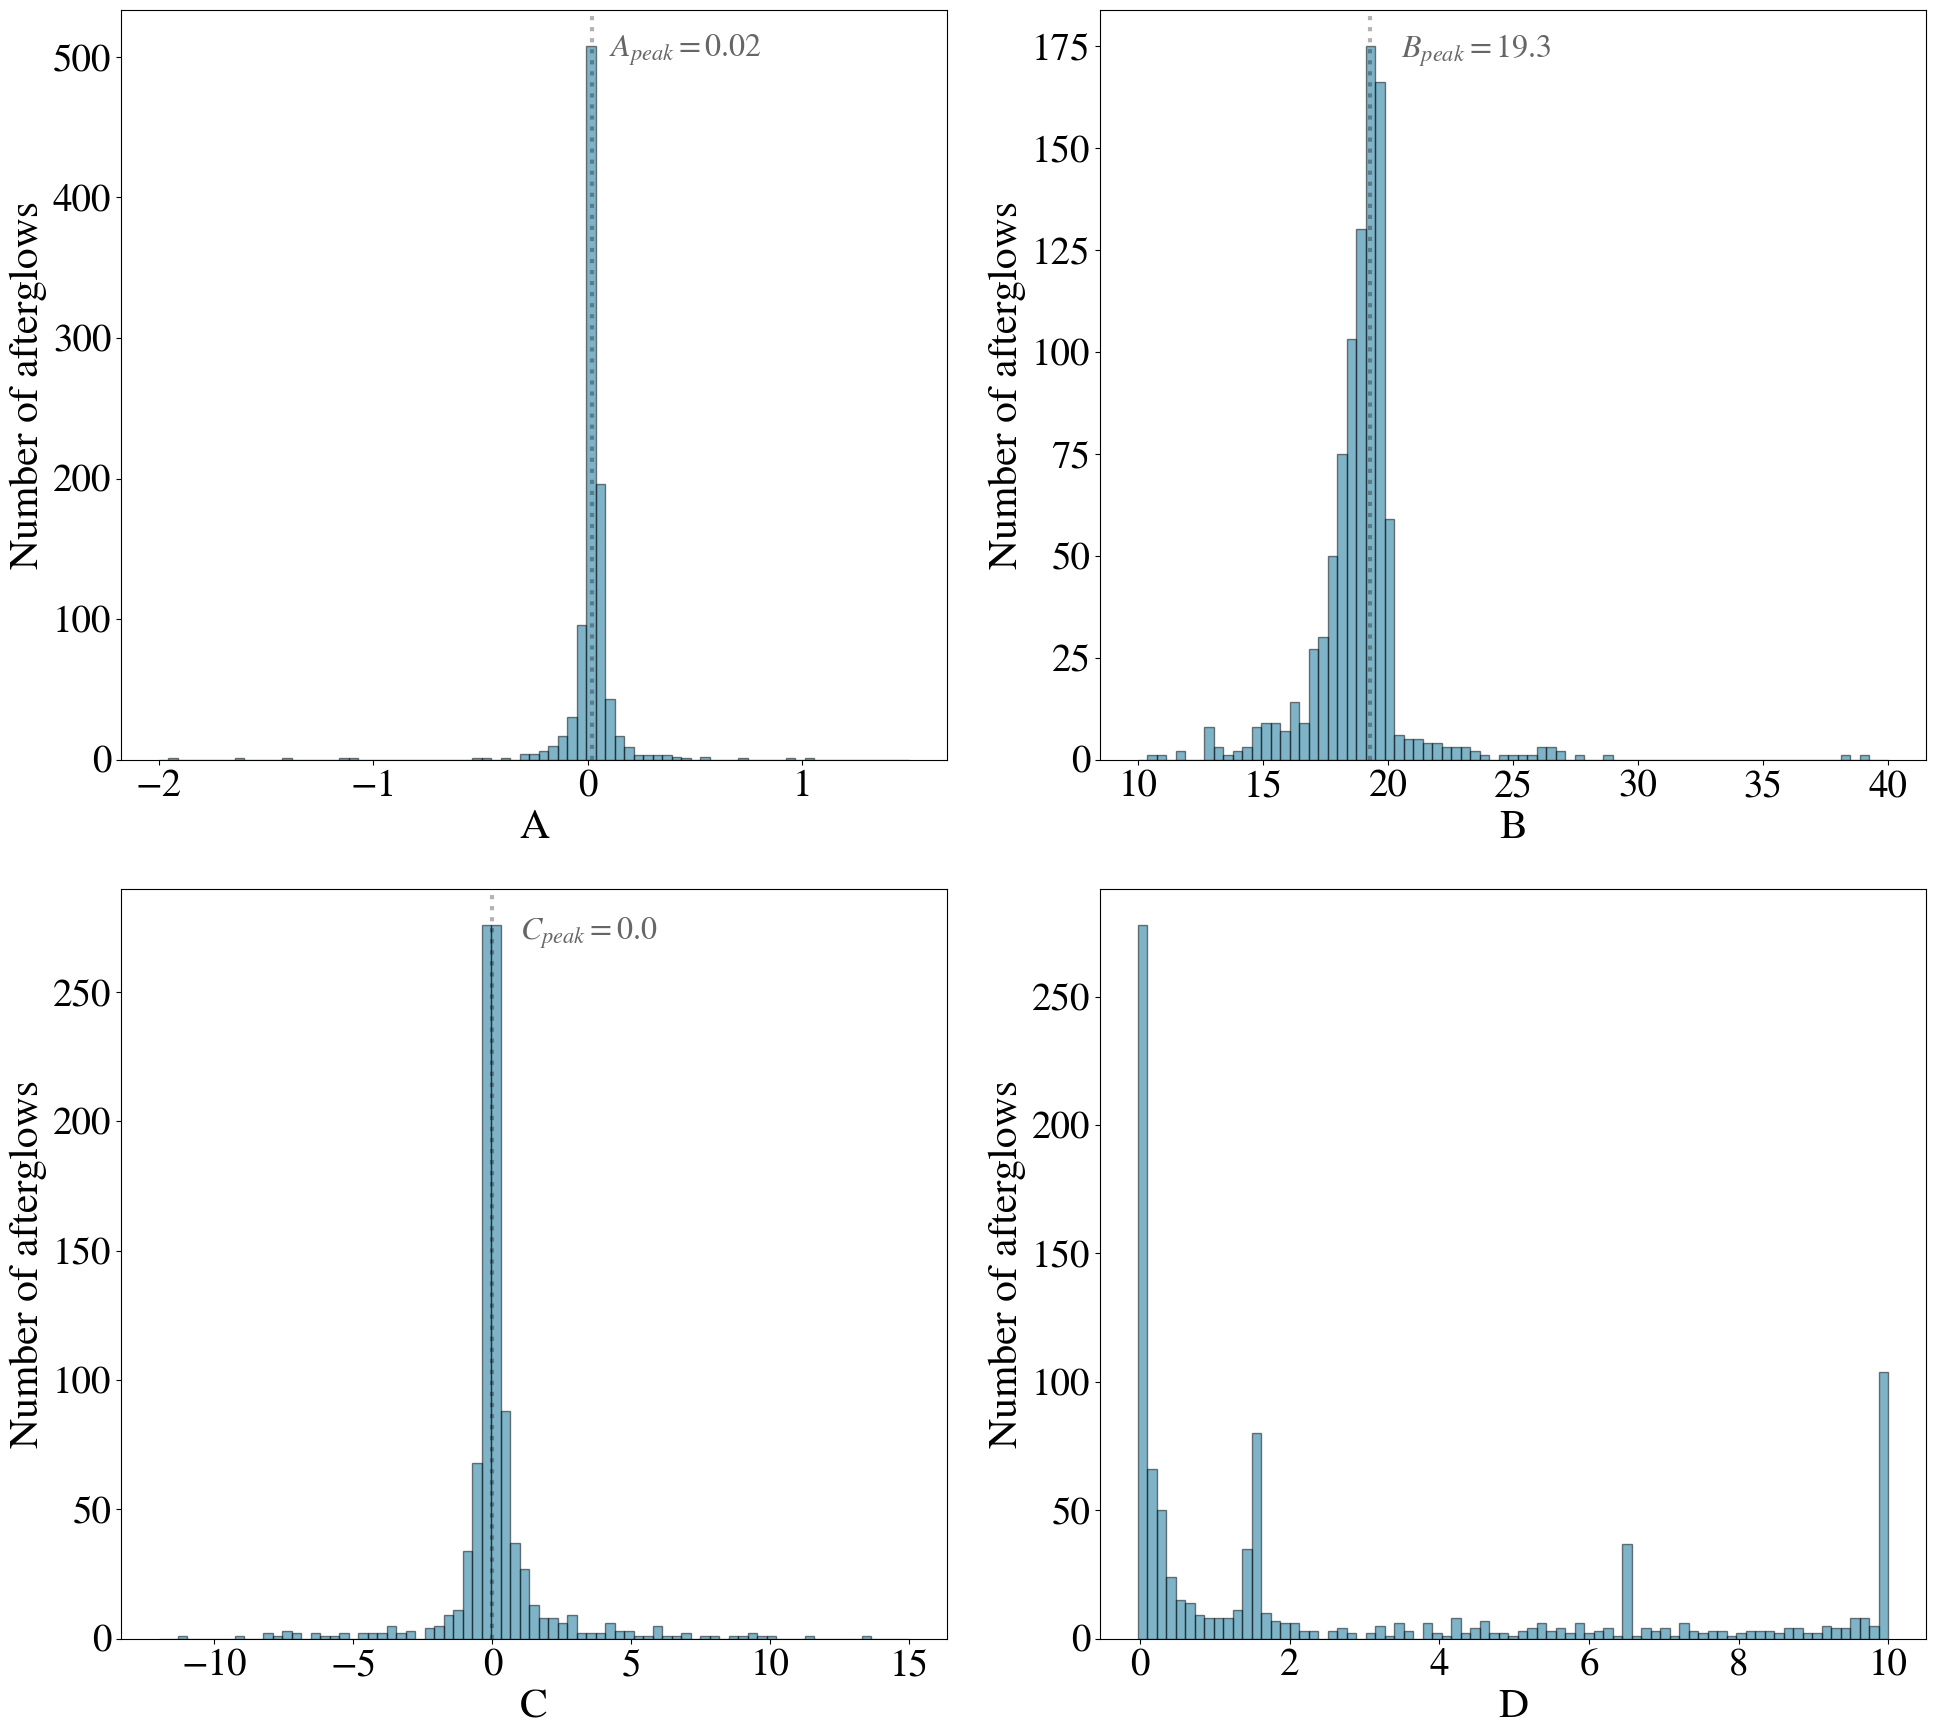

In [60]:
params = [A, B, C, D]
labels = ['A', 'B', 'C', 'D']

plt.rcParams.update({'font.size': 28})
fig, axes = plt.subplots(figsize=(20,18), nrows=2, ncols=2)

for i in range(4):
    
    ax = axes[i//2, i%2]
    
    if i==0:
        bin_edges = np.linspace(-2, 1.5, 80)
        ax.hist(params[i], bins=bin_edges, color='#006b93', alpha=0.5, edgecolor='black')
        ax.set_xlabel(labels[i], fontsize=30)
        ax.axvline(x=0.02, color='k', alpha=0.3, lw=3, ls=':')
        ax.text(0.1, 500, '$A_{peak}=0.02$', color='k', alpha=0.6, fontsize=23)
        
    elif i==1:      
        bin_edges = np.linspace(10, 40, 80)
        ax.hist(params[i], bins=bin_edges, color='#006b93', alpha=0.5, edgecolor='black')
        ax.set_xlabel(labels[i], fontsize=30)
        ax.axvline(x=19.3, color='k', alpha=0.3, lw=3, ls=':')
        ax.text(20.5, 172, '$B_{peak}=19.3$', color='k', alpha=0.6, fontsize=23)
        
    elif i==2:
        bin_edges = np.linspace(-12, 15, 80)
        ax.hist(params[i], bins=bin_edges, color='#006b93', alpha=0.5, edgecolor='black')
        ax.set_xlabel(labels[i], fontsize=30)
        ax.axvline(x=0.0, color='k', alpha=0.3, lw=3, ls=':')
        ax.text(1, 270, '$C_{peak}=0.0$', color='k', alpha=0.6, fontsize=23)
        
    elif i==3:
        bin_edges = np.linspace(-0.03, 10, 80)
        ax.hist(params[i], bins=bin_edges, color='#006b93', alpha=0.5, edgecolor='black')
        ax.set_xlabel(labels[i], fontsize=30)
    
    ax.set_ylabel('Number of afterglows', fontsize=30)
    #ax.set_xscale('log')
    #ax.set_ylim(30, 16)
    
plt.tight_layout() 

#plt.savefig('../../afterglowpy/figures/function_params_distrib_ztf_alerts.pdf', format="pdf", bbox_inches="tight", transparent=True)

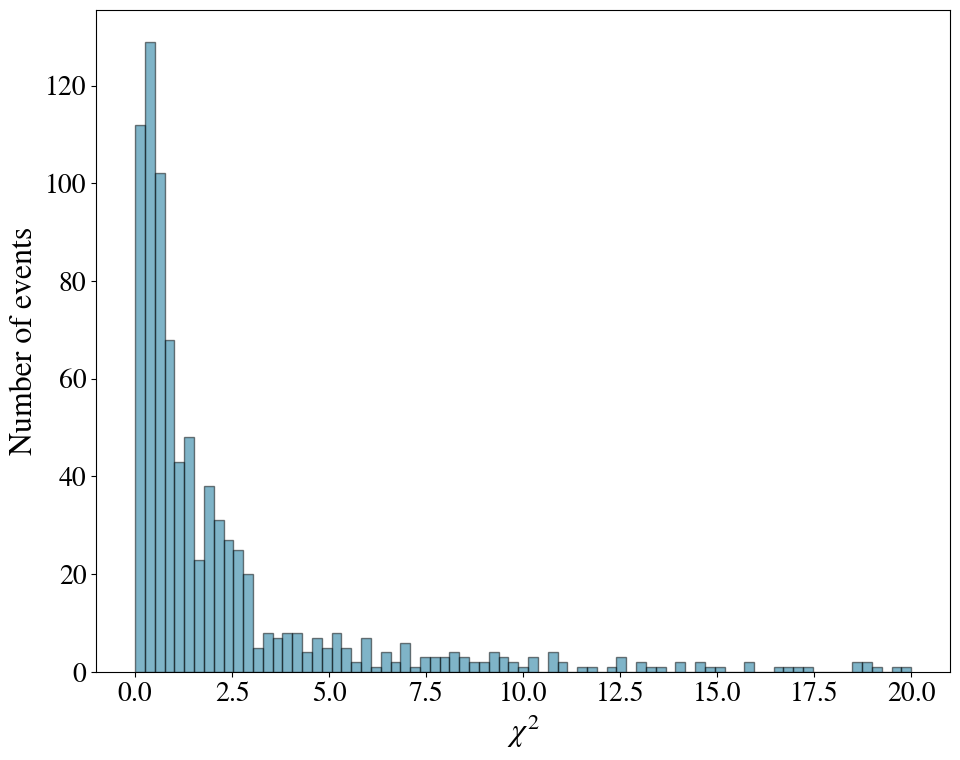

In [61]:
plt.rcParams.update({'font.size': 20})
plt.figure(figsize=(10, 8))

bin_edges = np.linspace(0., 20, 80)

plt.hist(chi2, bins=bin_edges, color='#006b93', alpha=0.5, edgecolor='black')
plt.xlabel("$\chi^2$", fontsize=23)
plt.ylabel("Number of events", fontsize=23)

#plt.axvline(x=15, lw=2, color="gray", ls='--', alpha=0.6)
#plt.text(17, 80, "15 days", rotation='vertical', fontsize=20, color='gray')

plt.tight_layout()

#plt.savefig("../../afterglowpy/figures/chi2_distrib_ztf_alerts.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()

In [174]:
lc_ztf

,obj,time,mags,mags_err,filt,duration,g-r,r-i,A,B,C,D,chi2,increase_rate,decrease_rate_1,decrease_rate_3,A/B
1,ZTF25aaqkrze,"[2460820.9389005, 2460820.891956, 2460826.9020...","[18.816198348999023, 18.937110900878906, 19.03...","[0.06286535412073135, 0.06951691955327988, 0.1...","[r, g, g, g, r, r, r, r, g, r, g, g, g, r, g, ...",0.000000,-0.226037,NaN,0.049588,18.450465,0.593330,0.353259,1.424129,-0.007099,0.002716,0.009636,0.002688
2,ZTF25aaqemtu,"[2460817.8029977, 2460814.7914352, 2460821.773...","[19.547832489013672, 19.639507293701172, 19.32...","[0.11139839142560959, 0.2130787968635559, 0.11...","[g, g, g, g, g, g]",6.982419,NaN,NaN,-0.010103,19.428526,-0.092746,-0.000717,1.421440,-0.007585,0.000000,0.000000,-0.000520
6,ZTF25aasbffv,"[2460842.6939699, 2460851.6742593, 2460845.755...","[18.785743713378906, 19.200807571411133, 18.91...","[0.08912719786167145, 0.15062417089939117, 0.1...","[r, r, r, g, r, g, r, r, r, g, g, r, g, g, g, ...",6.001875,-0.145575,NaN,0.056289,17.976253,0.673255,1.210572,0.730038,-0.008419,0.018036,0.011979,0.003131
7,ZTF25aaglicm,"[2460796.7960301, 2460798.7935185, 2460816.772...","[19.759605407714844, 19.80546760559082, 20.003...","[0.10664847493171692, 0.15873266756534576, 0.1...","[r, r, r, r, r]",0.000000,NaN,NaN,0.008049,19.806140,-0.046366,0.509540,NaN,-0.000244,0.000000,0.000000,0.000406
9,ZTF25aarxyue,"[2460832.8616898, 2460850.8574653, 2460832.793...","[18.66661834716797, 19.594676971435547, 18.827...","[0.1356334239244461, 0.12517870962619781, 0.09...","[g, r, r, r, g, r, g, g, g, r, g, g, r, g, r]",0.000000,-0.030313,NaN,0.084806,17.044940,2.182148,0.087890,1.259623,0.000000,0.001775,0.012473,0.004975
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2610,ZTF25aavspfv,"[2460853.8414352, 2460851.8365509, 2460849.775...","[19.54403305053711, 19.643844604492188, 19.896...","[0.11216419190168381, 0.1356380432844162, 0.14...","[r, r, r, r, g, r, r, g, g]",7.958935,-0.031487,NaN,-0.076022,19.927954,-0.028800,5.589846,1.729788,-0.007995,0.000000,0.000000,-0.003815
2611,ZTF25aasfkmy,"[2460850.9363542, 2460834.960625, 2460844.9000...","[18.45162010192871, 17.76874542236328, 18.3339...","[0.06707126647233963, 0.028205329552292824, 0....","[r, r, r, g, r, g, r, g, g, g, g, r, g, g, r, ...",11.936724,1.151777,NaN,0.046569,17.338466,0.674386,7.254354,5.083257,-0.001831,0.015307,0.019257,0.002686
2613,ZTF25aapqqjw,"[2460820.6820949, 2460815.6816319, 2460822.753...","[19.57213020324707, 19.29234504699707, 19.3618...","[0.1750354766845703, 0.1262696087360382, 0.159...","[g, g, g, g, r, g]",0.000000,0.379784,NaN,-0.000438,19.210466,-0.399166,9.999683,1.333201,0.000000,0.000000,0.000000,-0.000023
2617,ZTF25aavhnve,"[2460848.7946528, 2460847.8188194, 2460848.836...","[19.16620445251465, 19.065298080444336, 19.239...","[0.08856041729450226, 0.11144764721393585, 0.0...","[r, r, g, g, r, r, g, r, r, r, r, r, g, r, g, ...",6.969595,0.078472,NaN,-0.027605,19.224090,0.359622,9.999646,1.431929,-0.083817,0.000000,0.000000,-0.001436


In [146]:
lc_ztf['duration'] = dt_po
lc_ztf['increase_rate'] = rate_i
lc_ztf['decrease_rate_1'] = rate_d1
lc_ztf['decrease_rate_3'] = rate_d3
lc_ztf['g-r'] = gr
lc_ztf['r-i'] = ri
lc_ztf['A'] = A
lc_ztf['B'] = B
lc_ztf['C'] = C
lc_ztf['D'] = D
lc_ztf['A/B'] = lc_ztf['A']/lc_ztf['B']
lc_ztf['chi2'] = chi2

/tmp/ipykernel_459987/197754510.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lc_ztf['duration'] = dt_po
/tmp/ipykernel_459987/197754510.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lc_ztf['increase_rate'] = rate_i
/tmp/ipykernel_459987/197754510.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/ind

In [148]:
lc_ztf = lc_ztf.drop(columns=['rate_inc', 'rate_dec_1', 'rate_dec_3'])

In [69]:
df_orphans_ztf = pd.read_pickle('/home/masson/orphans/data/pseudo_obs/orphan_pseudo_obs_features_ztf.pkl')
df_alerts_ztf = pd.read_pickle(f'/home/masson/orphans/data/ztf_alerts_lc_features.pkl')

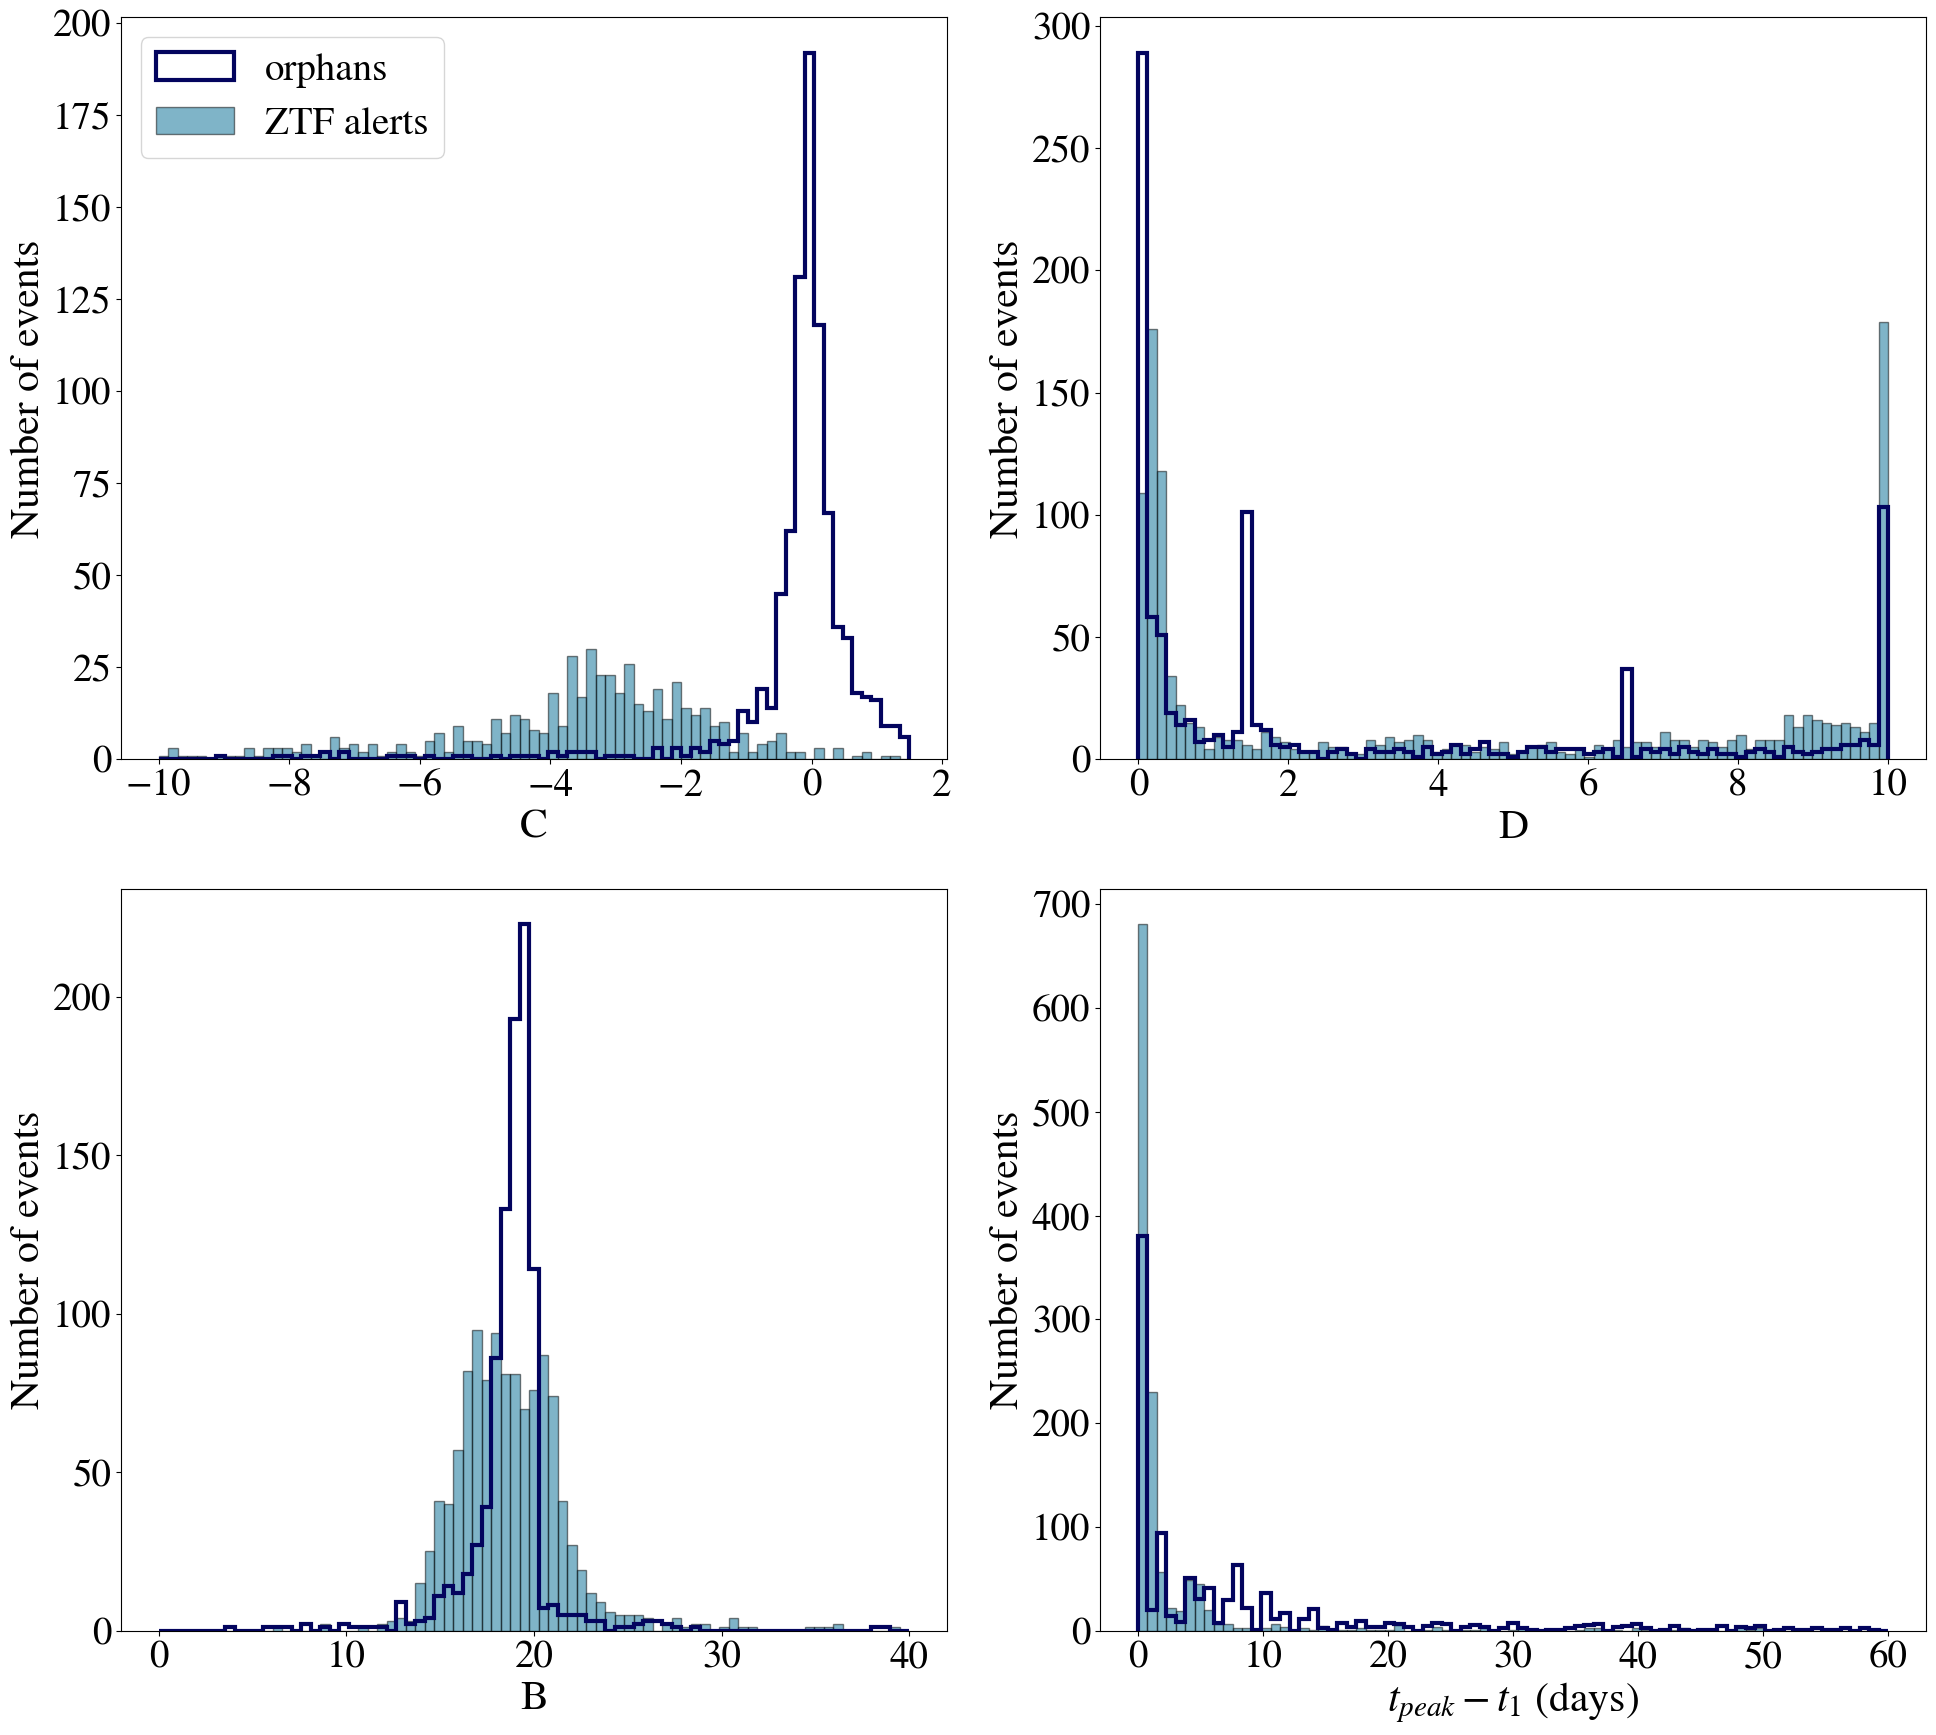

In [87]:
params_oa_ztf = [df_orphans_ztf['C'], df_orphans_ztf['D'], df_orphans_ztf['B'], df_orphans_ztf['duration']]
params_ztf = [df_alerts_ztf['C'], df_alerts_ztf['D'], df_alerts_ztf['B'], df_alerts_ztf['duration']]
labels = ['C', 'D', 'B', '$t_{peak}-t_1$ (days)']

plt.rcParams.update({'font.size': 28})
fig, axes = plt.subplots(figsize=(20,18), nrows=2, ncols=2)

for i in range(4):
    
    ax = axes[i//2, i%2]
    
    if i==0:
        bin_edges = np.linspace(-10, 1.5, 80)
        ax.hist(params_ztf[i], bins=bin_edges, histtype='step', color='#03045e', lw=3, label='orphans')
        ax.hist(params_oa_ztf[i], bins=bin_edges, color='#006b93', alpha=0.5, edgecolor='black', label='ZTF alerts')
        ax.set_xlabel(labels[i], fontsize=30)
        ax.legend(loc='upper left')
        
    elif i==1:      
        bin_edges = np.linspace(-0.01, 10.01, 80)
        ax.hist(params_ztf[i], bins=bin_edges, histtype='step', color='#03045e', lw=3)
        ax.hist(params_oa_ztf[i], bins=bin_edges, color='#006b93', alpha=0.5, edgecolor='black')
        ax.set_xlabel(labels[i], fontsize=30)
        
    elif i==2:
        bin_edges = np.linspace(-0, 40, 80)
        ax.hist(params_ztf[i], bins=bin_edges, histtype='step', color='#03045e', lw=3)
        ax.hist(params_oa_ztf[i], bins=bin_edges, color='#006b93', alpha=0.5, edgecolor='black')
        ax.set_xlabel(labels[i], fontsize=30)
        
    elif i==3:
        bin_edges = np.linspace(-0.03, 60, 80)
        ax.hist(params_ztf[i], bins=bin_edges, histtype='step', color='#03045e', lw=3)
        ax.hist(params_oa_ztf[i], bins=bin_edges, color='#006b93', alpha=0.5, edgecolor='black')
        ax.set_xlabel(labels[i], fontsize=30)
    
    ax.set_ylabel('Number of events', fontsize=30)
    #ax.set_xscale('log')
    #ax.set_ylim(30, 16)
    
plt.tight_layout() 

#plt.savefig('../../afterglowpy/figures/function_params_distrib_ztf_alerts.pdf', format="pdf", bbox_inches="tight", transparent=True)

In [19]:
def rescale_filters(times, mags, mags_err, filts):
    """
    Calculate the rescaled magnitude to the r-band

    Parameters
    ----------
    times: list of float
        Concatenated times in MJD for the object
    mags: list of float
        Concatenated magnitudes for the object
    mags_err: list of float
        Concatenated magnitude errors for the object
    filts: list of float
        Concatenated filters for the object

    Returns
    -------
    time: array
        Array containing all the times of the rescaled points from 0 (0 being the time of the first alert)
    mag_r: array
        Array containing the rescaled magnitudes
    err: array
        Array containing the errors associated to the points
    """

    # mean frequencies for filters: g, r, i
    filters = ['u', 'g', 'r', 'i', 'z', 'y']
    mean_nu = [840336134453781.4, 629326620516047.8, 482703137570394.2, 397614314115308.1, 344530577088716.56, 298760145396604.1]
    nu_dict = dict(zip(filters, mean_nu))

    # get r-band data
    is_r = filts == 'r'
    flux_r = mag_to_flux(mags[is_r])
    time_r = times[is_r]

    p = 2.2
    beta_range = np.linspace(-(p-1)/2, -p/2, 100)
    best_d = np.inf
    best_beta = None

    # choose the filter to rescale (with most data)
    filt_obs = filts[filts != 'r']
    if filt_obs.size > 0:
        unique, counts = np.unique(filt_obs, return_counts=True)
        filt_max = unique[np.argmax(counts)]
    else:
        filt_max = None

    if filt_max is not None:
        idx = filts == filt_max
        flux_filt = mag_to_flux(mags[idx])
        time_filt = times[idx]

        for b in beta_range:
            flux_rescaled = flux_filt * (nu_dict['r'] / nu_dict[filt_max]) ** b
            d = np.sum(np.sqrt((time_filt[:, np.newaxis] - time_r[np.newaxis, :])**2 +
                               (flux_rescaled[:, np.newaxis] - flux_r[np.newaxis, :])**2))
            if d < best_d:
                best_d = d
                best_beta = b

        # rescale all bands
        rescaled_flux = []
        rescaled_time = []
        rescaled_err = []

        for f in filters:
            idx = filts == f
            f_flux = mag_to_flux(mags[idx])
            f_time = times[idx]
            f_err = mags_err[idx]

            if f == 'r':
                rescaled_flux.append(f_flux)
            else:
                rescaled_flux.append(f_flux * (nu_dict['r'] / nu_dict[f]) ** best_beta)

            rescaled_time.append(f_time)
            rescaled_err.append(f_err)

        all_time = np.concatenate(rescaled_time)
        all_flux = np.concatenate(rescaled_flux)
        all_mags = flux_to_mag(all_flux)
        all_err = np.concatenate(rescaled_err)
        
        return all_time - min(all_time), all_mags, all_err

    else:

        return times - min(times), mags, mags_err


def model(t, params):
    """Function used to fit the light curve

    Parameters
    ----------
    t: list of float
        Concatenated time for the object
    params: tuple of float
        Parameters of the function, to estimate
    """

    A, B, C, D = params
    return A * t + B + C * np.exp(-D * t)


def fit_light_curve(times, mags, mags_err, filts):
    """
    Fit the light curve using an MCMC method

    Parameters
    ----------
    time: list of float
        Concatenated times in MJD for the object
    mags: list of float
        Concatenated magnitudes for the object
    err: list of float
        Concatenated magnitude errors for the object
    filt: list of float
        Concatenated filters for the object

    Returns
    -------
    A, B, C, D: float
        Parameters of the function to fit
    chi2: float
        Chi square calculated as chi2 = sum(((y - y_fit) / y_err)²)
    """

    t, y, yerr = rescale_filters(times, mags, mags_err, filts)

    least_squares = LeastSquares(t, y, yerr, model)

    initial = np.array([0.02, 20., 0., 1.5])
    m = Minuit(least_squares, initial, name=('A', 'B', 'C', 'D'))

    m.limits = [(-1e4, 1e4), (-1e6, 1e6), (-1e7, 1e7), (-0.03, 10.)]

    m.migrad()  # finds minimum of least_squares function
    m.hesse()  # accurately computes uncertainties

    n_try = 0
    while (m.fmin.reduced_chi2 > 3.):
        if (n_try < 10):
            n_try += 1
            initial += 0.5
            m = Minuit(least_squares, initial, name=('A', 'B', 'C', 'D'))

            m.limits = [(-1e4, 1e4), (-1e6, 1e6), (-1e7, 1e7), (-0.03, 10.)]

            m.migrad();  # finds minimum of least_squares function
            m.hesse();  # accurately computes uncertainties
        else:
            break

    A = m.values[0]
    B = m.values[1]
    C = m.values[2]
    D = m.values[3]
    chi2 = m.fmin.reduced_chi2

    return A, B, C, D, chi2

In [36]:
df_list = pd.read_pickle('/home/masson/afterglowpy/data/orphans_pseudo_obs_5pts_low_redshift.pkl')
df = pd.DataFrame(df_list)

In [67]:
A, B, C, D = [], [], [], []
chi2 = []

filter_colours = {'b': 'u', 'c': 'g', 'g': 'r', 'orange': 'i', 'r': 'z', 'm': 'y'}

for i in range(len(df)):
    p = df.iloc[i]
    
    mags_var = np.array(p['mags_var'])
    mags_lim = p['mags_lim']
    times = np.array(p['time'])
    mags_err = np.array(p['mags_err'])
    colours = np.array(p['filt'])
    
    # detectable mags
    mask_mag = mags_var < mags_lim
    
    times_mag = times[mask_mag]
    mags_mag = mags_var[mask_mag]
    mags_err_mag = mags_err[mask_mag]
    colours_mag = colours[mask_mag]
    
    if times_mag.size > 0:
        # < 60 days after first detection
        mask_time = (times_mag - times_mag[0]) < 60
        
        times_sel = times_mag[mask_time]
        mags_sel = mags_mag[mask_time]
        mags_err_sel = mags_err_mag[mask_time]
        colours_sel = colours_mag[mask_time]
        
        filts = [filter_colours[c] for c in colours_sel]
        
        if times_sel.size > 0:
            a, b, c, d, x2 = fit_light_curve(times_sel, mags_sel, mags_err_sel, np.array(filts))
            A.append(a)
            B.append(b)
            C.append(c)
            D.append(d)
            chi2.append(x2)
        else:
            A.append(np.nan)
            B.append(np.nan)
            C.append(np.nan)
            D.append(np.nan)
            chi2.append(np.nan)
    else:
        A.append(np.nan)
        B.append(np.nan)
        C.append(np.nan)
        D.append(np.nan)
        chi2.append(np.nan)

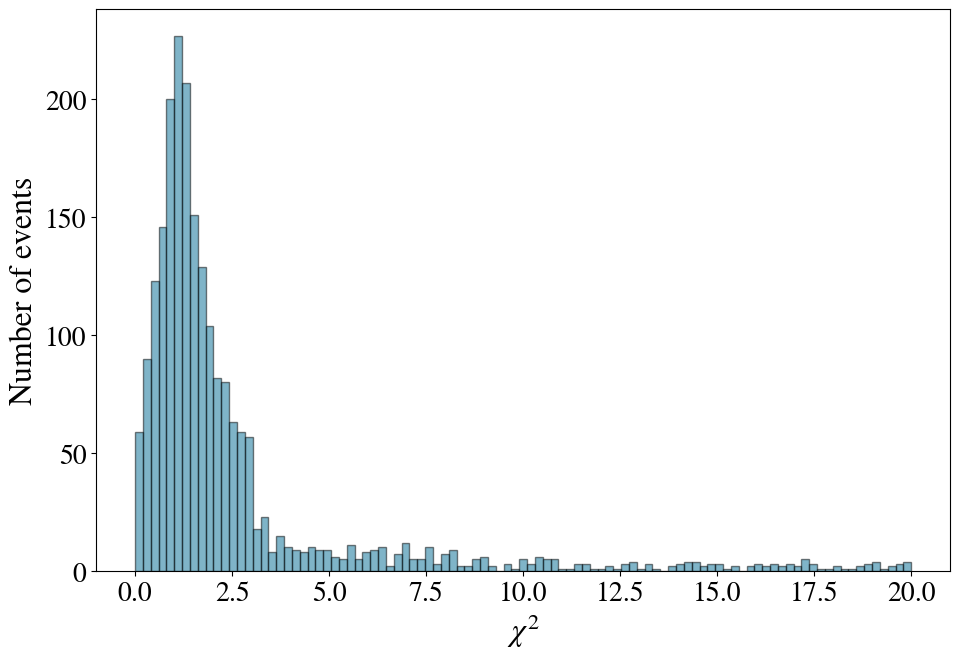

In [95]:
plt.rcParams.update({'font.size': 20})
plt.figure(figsize=(10, 7))

bin_edges = np.linspace(0., 20, 100)

plt.hist(chi2, bins=bin_edges, color='#006b93', alpha=0.5, edgecolor='black')
plt.xlabel("$\chi^2$", fontsize=23)
plt.ylabel("Number of events", fontsize=23)
#plt.axvline(x=1)

plt.tight_layout()

#plt.savefig("../../afterglowpy/figures/chi2_distrib_mags_var.pdf", format="pdf", bbox_inches="tight", transparent=True)
plt.show()

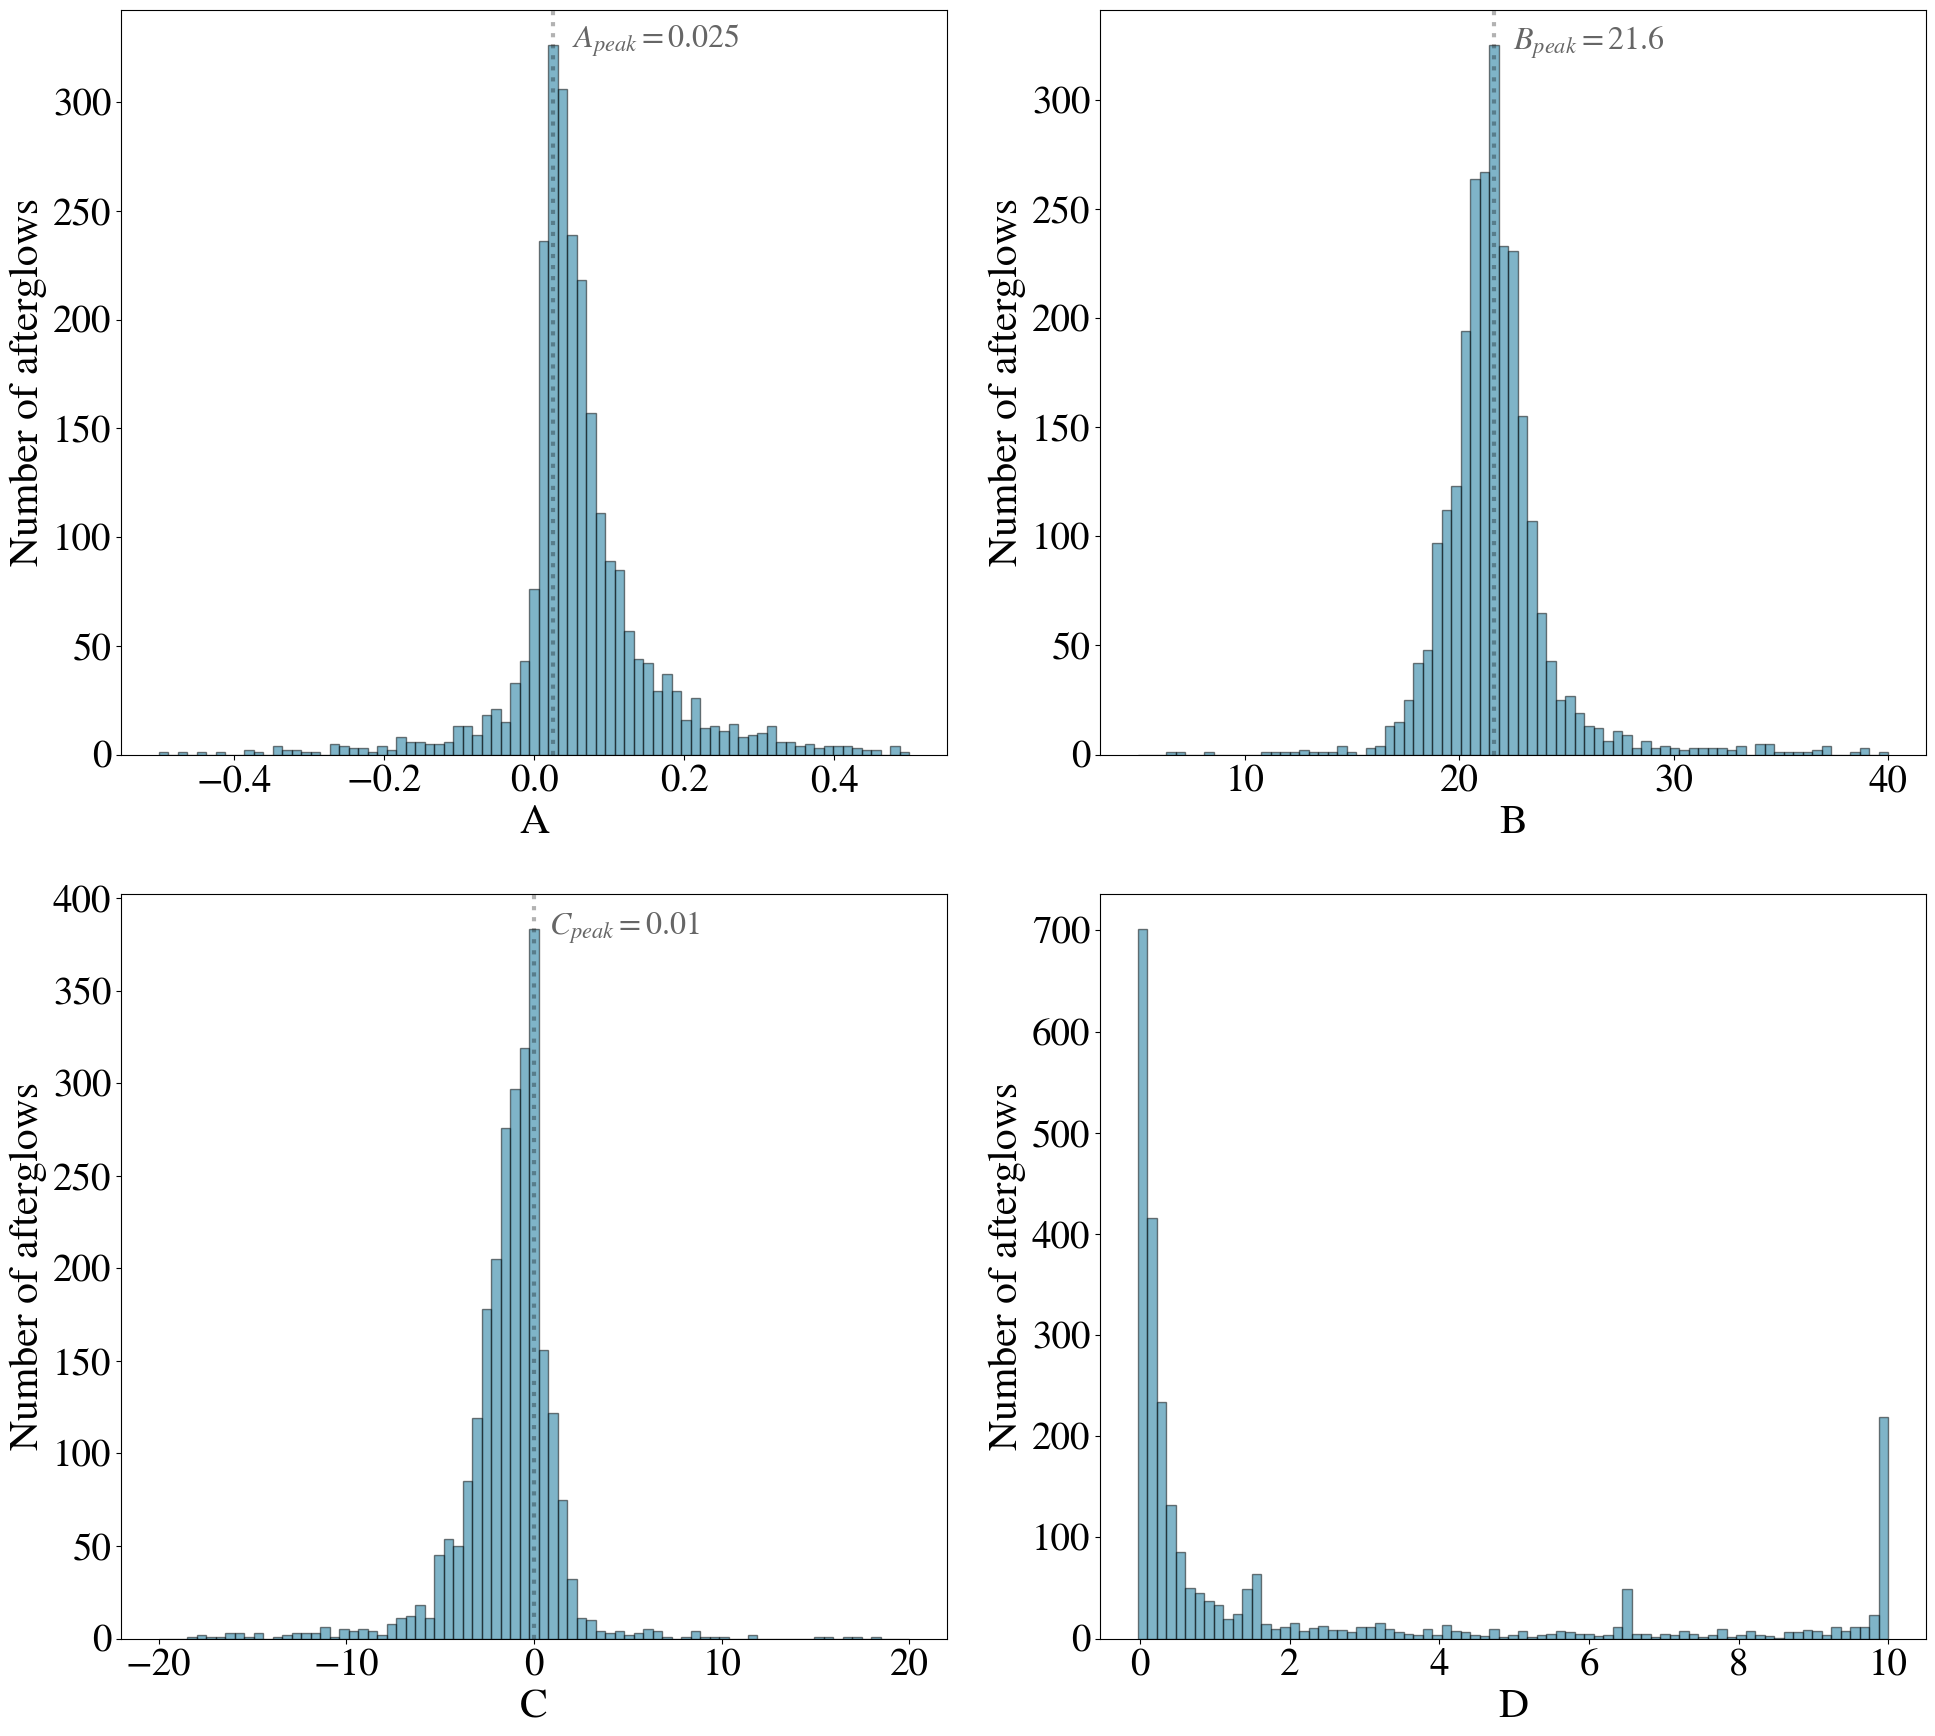

In [93]:
params = [A, B, C, D]
labels = ['A', 'B', 'C', 'D']

plt.rcParams.update({'font.size': 28})
fig, axes = plt.subplots(figsize=(20,18), nrows=2, ncols=2)

for i in range(4):
    
    ax = axes[i//2, i%2]
    
    if i==0:
        bin_edges = np.linspace(-0.5, 0.5, 80)
        ax.hist(params[i], bins=bin_edges, color='#006b93', alpha=0.5, edgecolor='black')
        ax.set_xlabel(labels[i], fontsize=30)
        ax.axvline(x=0.025, color='k', alpha=0.3, lw=3, ls=':')
        ax.text(0.05, 325, '$A_{peak}=0.025$', color='k', alpha=0.6, fontsize=23)
        
    elif i==1:      
        bin_edges = np.linspace(5, 40, 80)
        ax.hist(params[i], bins=bin_edges, color='#006b93', alpha=0.5, edgecolor='black')
        ax.set_xlabel(labels[i], fontsize=30)
        ax.axvline(x=21.6, color='k', alpha=0.3, lw=3, ls=':')
        ax.text(22.5, 323, '$B_{peak}=21.6$', color='k', alpha=0.6, fontsize=23)
        
    elif i==2:
        bin_edges = np.linspace(-20, 20, 80)
        ax.hist(params[i], bins=bin_edges, color='#006b93', alpha=0.5, edgecolor='black')
        ax.set_xlabel(labels[i], fontsize=30)
        ax.axvline(x=0.01, color='k', alpha=0.3, lw=3, ls=':')
        ax.text(0.8, 380, '$C_{peak}=0.01$', color='k', alpha=0.6, fontsize=23)
        
    elif i==3:
        bin_edges = np.linspace(-0.03, 10, 80)
        ax.hist(params[i], bins=bin_edges, color='#006b93', alpha=0.5, edgecolor='black')
        ax.set_xlabel(labels[i], fontsize=30)
    
    ax.set_ylabel('Number of afterglows', fontsize=30)
    #ax.set_xscale('log')
    #ax.set_ylim(30, 16)
    
plt.tight_layout() 

#plt.savefig('../../afterglowpy/figures/fit_params_distrib_mags_var.pdf', format="pdf", bbox_inches="tight", transparent=True)

In [8]:
df = pd.read_pickle('/home/masson/afterglowpy/data/orphans_elasticc_features.pkl')
df_orphans_jetsimpy = pd.read_pickle('/home/masson/jetsimpy/orphan_pop/data/features_jetsimpy.pkl')

In [10]:
df_orphans_afterglowpy = df[df['type']=='orphans']

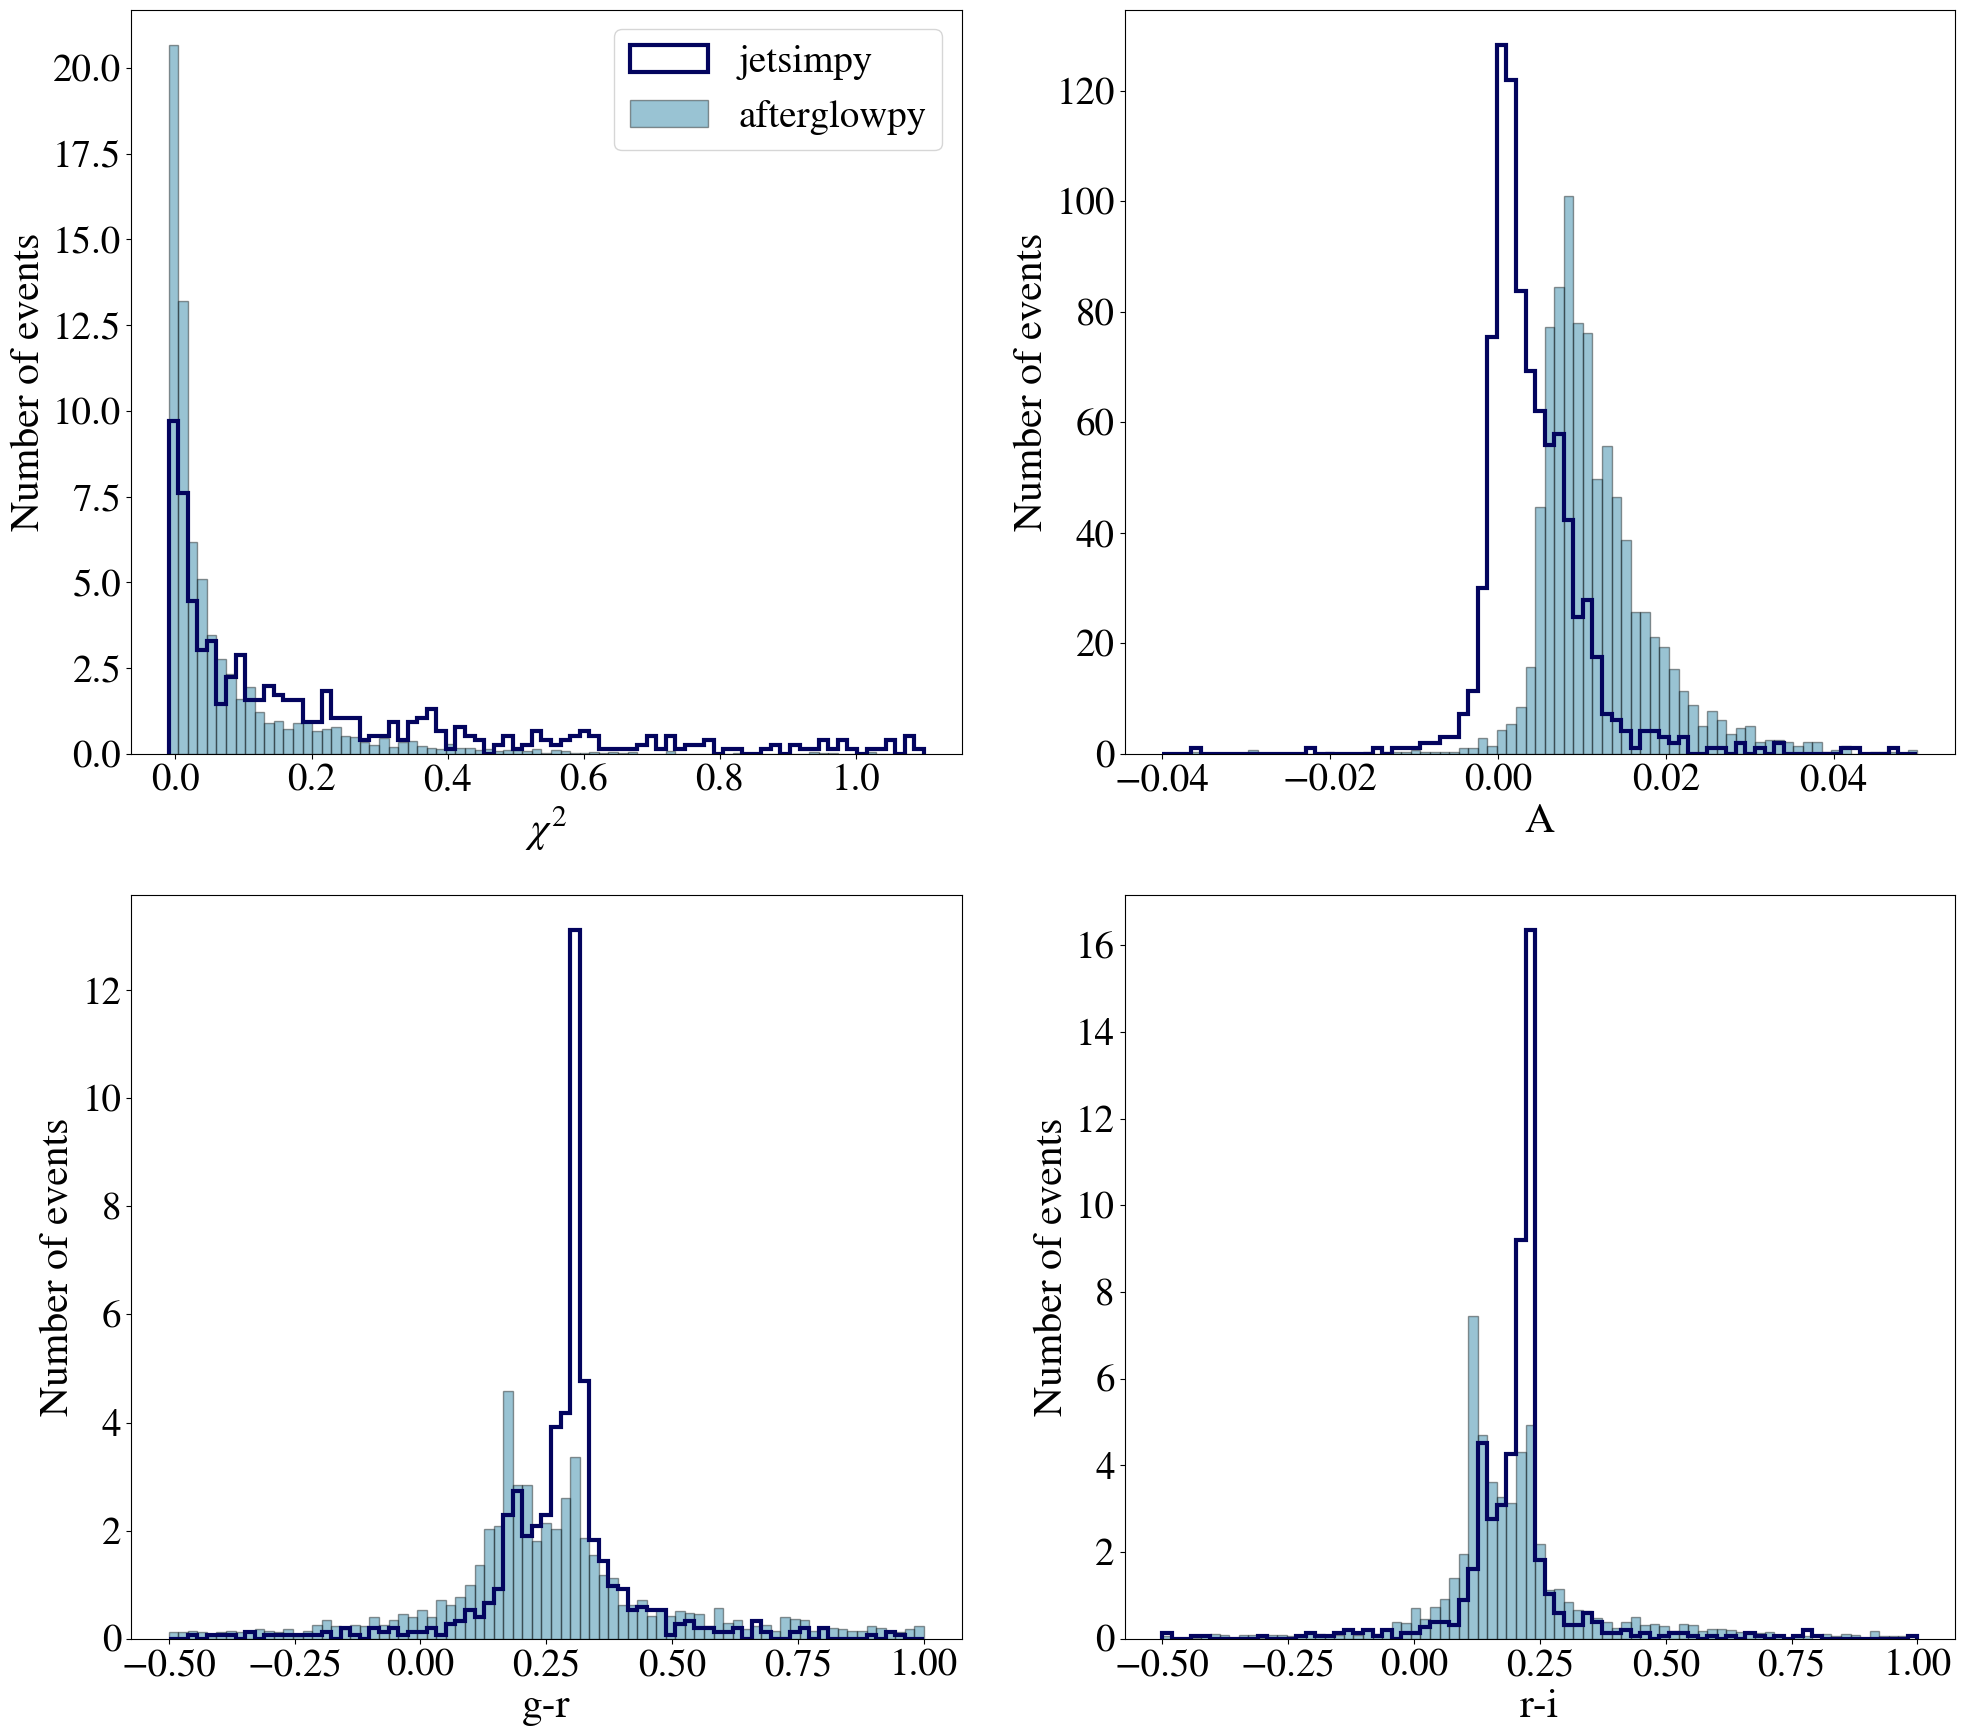

In [29]:
params_afterglowpy = [df_orphans_afterglowpy['chi2'], df_orphans_afterglowpy['A'], df_orphans_afterglowpy['g-r'], df_orphans_afterglowpy['r-i']]
params_jetsimpy = [df_orphans_jetsimpy['chi2'], df_orphans_jetsimpy['A'], df_orphans_jetsimpy['g-r'], df_orphans_jetsimpy['r-i']]
labels = [r'$\chi^2$', 'A', 'g-r', 'r-i']

plt.rcParams.update({'font.size': 28})
fig, axes = plt.subplots(figsize=(20,18), nrows=2, ncols=2)

for i in range(4):
    
    ax = axes[i//2, i%2]
    
    if i==0:
        bin_edges = np.linspace(-0.01, 1.1, 80)
        ax.hist(params_jetsimpy[i], bins=bin_edges, density=True, histtype='step', color='#03045e', linewidth=3, label='jetsimpy')
        ax.hist(params_afterglowpy[i], bins=bin_edges, density=True, color='#006b93', alpha=0.4, edgecolor='black', label='afterglowpy')
        ax.set_xlabel(labels[i], fontsize=30)
        ax.legend(loc='upper right')
        
    elif i==1:      
        bin_edges = np.linspace(-0.04, 0.05, 80)
        ax.hist(params_jetsimpy[i], bins=bin_edges, density=True, histtype='step', color='#03045e', linewidth=3, label='jetsimpy')
        ax.hist(params_afterglowpy[i], bins=bin_edges, density=True, color='#006b93', alpha=0.4, edgecolor='black', label='afterglowpy')
        ax.set_xlabel(labels[i], fontsize=30)
        
    elif i==2:
        bin_edges = np.linspace(-0.5, 1., 80)
        ax.hist(params_jetsimpy[i], bins=bin_edges, density=True, histtype='step', color='#03045e', linewidth=3, label='jetsimpy')
        ax.hist(params_afterglowpy[i], bins=bin_edges, density=True, color='#006b93', alpha=0.4, edgecolor='black', label='afterglowpy')
        ax.set_xlabel(labels[i], fontsize=30)
        
    elif i==3:
        bin_edges = np.linspace(-0.5, 1., 80)
        ax.hist(params_jetsimpy[i], bins=bin_edges, density=True, histtype='step', color='#03045e', linewidth=3, label='jetsimpy')
        ax.hist(params_afterglowpy[i], bins=bin_edges, density=True, color='#006b93', alpha=0.4, edgecolor='black', label='afterglowpy')
        ax.set_xlabel(labels[i], fontsize=30)
    
    ax.set_ylabel('Number of events', fontsize=30)
    #ax.set_xscale('log')
    #ax.set_ylim(30, 16)
    
plt.tight_layout() 

#plt.savefig('../../afterglowpy/figures/afterglowpy_jetsimpy_features.png', bbox_inches="tight", transparent=True)